# Comprehensive EDA Notebook: Hillstrom Email Marketing Uplift Dataset

**Project:** Uplift Modeling with the Hillstrom Email Marketing Dataset  
**Purpose:** Use exploratory data analysis to answer the project proposal questions, instructor feedback, and the main campaign/uplift questions before final modeling.

This notebook is intentionally written as a project deliverable. It combines code, graphs, descriptive tables, and interpretation markdown so it can be read by a teammate or professor without needing a separate explanation.

## Executive summary from the data

This notebook answers the project's EDA and proposal questions using the Hillstrom email marketing CSV.

**Main findings:**

- The dataset has **64,000 customers** and **12 original columns**. The three campaign arms are almost perfectly balanced: **21,307 Men's Email**, **21,387 Women's Email**, and **21,306 No Email control**.
- The randomized groups look comparable on observed pre-treatment covariates. The largest pairwise standardized mean difference across `recency`, `history`, `mens`, `womens`, and `newbie` is only **0.009**. The largest Cramer's V across categorical features is **0.010**, which is also very small.
- Email treatment increased all three outcomes on average. Any email vs. control produced a visit lift of **6.09 pp**, a conversion lift of **0.50 pp**, and an average spend lift of **\$0.60 per contacted customer**.
- The **Men's Email** appears strongest overall: visit rate **18.28%** vs. control **10.62%**; conversion rate **1.25%** vs. control **0.57%**; average spend **\$1.42** vs. control **\$0.65**.
- The **Women's Email** also beats control on average, but by less: visit lift **4.52 pp**, conversion lift **0.31 pp**, and spend lift **$0.42**.
- The outcome is sparse: only **0.90%** of customers converted and **99.10%** had zero spend. This supports the proposal's choice to start with `visit` as the primary outcome and treat `conversion`/`spend` as secondary outcomes.
- Segment effects differ. Larger visit lifts show up among higher-history customers, prior women purchasers, multichannel customers, and many subgroups under the Men's Email. This supports the need for individualized uplift modeling rather than only average campaign comparisons.

## How this notebook answers the proposal and feedback

The project is not just asking *who is likely to visit or buy?* It is asking *who is likely to visit or buy because of the campaign?* This EDA is the first step before fitting uplift models.

The notebook directly answers these EDA questions:

1. How many customers are in each campaign group?
2. Are the Men's Email, Women's Email, and No Email groups balanced?
3. Are customer attributes similar across groups?
4. What are the average visit, conversion, and spend rates by campaign group?
5. Which campaign appears to perform best overall?
6. Are there differences by customer segment such as prior men's/women's purchases, new vs. returning customers, channel, zip type, history segment, and recency?

It also responds to the feedback by adding model-free causal estimates, confidence intervals, regression-ready setup, segment-level treatment effects, ROI sanity checks, and guidance for comparing more than one causal/uplift method in the final project.

## Analysis assumptions

- `segment` is the randomized campaign assignment.
- `No E-Mail` is the control group.
- `Mens E-Mail` and `Womens E-Mail` are treatment arms.
- `email = 1` means either Men's Email or Women's Email; `email = 0` means control.
- `visit`, `conversion`, and `spend` are post-campaign outcomes.
- Pre-treatment features are `recency`, `history`, `history_segment`, `mens`, `womens`, `zip_code`, `newbie`, and `channel`.
- The EDA can estimate average differences using the randomized experiment, but it does **not** observe individual counterfactuals. Individual-level uplift must be estimated by models later.

In [ ]:
# Core libraries
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, chi2_contingency
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Locate the CSV whether the notebook is run in /mnt/data or in the same folder as the CSV.
CSV_NAME = 'Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv'
CSV_CANDIDATES = [Path(CSV_NAME), Path('/mnt/data') / CSV_NAME]
CSV_PATH = next((p for p in CSV_CANDIDATES if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(f'Could not find {CSV_NAME}. Put the CSV in the same folder as this notebook or update CSV_PATH.')

print(f'Using CSV: {CSV_PATH}')

Using CSV: Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv


In [ ]:
# Helper functions used throughout the notebook.
def pct(x, digits=2):
    return f'{100*x:.{digits}f}%'

def pp(x, digits=2):
    return f'{100*x:.{digits}f} pp'

def dollars(x, digits=2):
    return f'${x:,.{digits}f}'

def smd(a, b):
    # Standardized mean difference between two numeric/binary arrays.
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    denom = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    if denom == 0 or np.isnan(denom):
        return np.nan
    return (a.mean() - b.mean()) / denom

def two_prop_diff_ci(y_t, n_t, y_c, n_c, alpha=0.05):
    # Difference in proportions: treated minus control.
    p_t = y_t / n_t
    p_c = y_c / n_c
    diff = p_t - p_c
    se = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)
    z = norm.ppf(1 - alpha/2)
    p_value = 2 * (1 - norm.cdf(abs(diff / se))) if se > 0 else np.nan
    return diff, diff - z * se, diff + z * se, p_value

def mean_diff_ci(x_t, x_c, alpha=0.05):
    # Welch mean difference: treated minus control.
    x_t = pd.Series(x_t).dropna()
    x_c = pd.Series(x_c).dropna()
    diff = x_t.mean() - x_c.mean()
    v_t = x_t.var(ddof=1)
    v_c = x_c.var(ddof=1)
    n_t = len(x_t)
    n_c = len(x_c)
    se = np.sqrt(v_t / n_t + v_c / n_c)
    df_num = (v_t / n_t + v_c / n_c) ** 2
    df_den = (v_t / n_t) ** 2 / (n_t - 1) + (v_c / n_c) ** 2 / (n_c - 1)
    df_welch = df_num / df_den
    crit = stats.t.ppf(1 - alpha/2, df_welch)
    p_value = stats.ttest_ind(x_t, x_c, equal_var=False).pvalue
    return diff, diff - crit * se, diff + crit * se, p_value

def cramers_v(table):
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.values.sum()
    r, k = table.shape
    v = np.sqrt((chi2 / n) / max(1, min(k - 1, r - 1)))
    return v, p

def label_bars(ax, fmt='{:.1f}'):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)

# 1. Load the dataset and inspect structure

This section answers the basic data availability, volume, and variable-type questions. The proposal describes this as a customer-level randomized email dataset with pre-campaign features, treatment assignment, and post-campaign outcomes.

In [ ]:
df = pd.read_csv(CSV_PATH)
df['email'] = (df['segment'] != 'No E-Mail').astype(int)
df['email_label'] = np.where(df['email'] == 1, 'Any E-Mail', 'No E-Mail')

segment_order = ['No E-Mail', 'Mens E-Mail', 'Womens E-Mail']
outcomes = ['visit', 'conversion', 'spend']
pre_treatment_features = ['recency', 'history', 'history_segment', 'mens', 'womens', 'zip_code', 'newbie', 'channel']

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')
display(df.head())

Rows: 64,000
Columns: 14


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,email,email_label
0,10,2) $100 - $200,142.4400,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0000,1,Any E-Mail
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000,0,No E-Mail
2,7,2) $100 - $200,180.6500,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0000,1,Any E-Mail
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000,1,Any E-Mail
4,2,1) $0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000,1,Any E-Mail


In [ ]:
# Data types, unique values, and missing values.
data_profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean(),
    'unique_values': df.nunique()
})
display(data_profile)

,dtype,missing_count,missing_pct,unique_values
recency,int64,0,0.0000,12
history_segment,object,0,0.0000,7
history,float64,0,0.0000,34833
mens,int64,0,0.0000,2
womens,int64,0,0.0000,2
zip_code,object,0,0.0000,3
newbie,int64,0,0.0000,2
channel,object,0,0.0000,3
segment,object,0,0.0000,3
visit,int64,0,0.0000,2


**Interpretation:** The data is clean for EDA: the loaded CSV has no missing values in the original columns. It includes a mix of numeric features (`recency`, `history`, `spend`), binary indicators (`mens`, `womens`, `newbie`, `visit`, `conversion`), categorical features (`history_segment`, `zip_code`, `channel`), and the randomized treatment assignment (`segment`).

In [ ]:
# Data dictionary aligned with the proposal.
data_dictionary = pd.DataFrame([
    ['recency', 'Input feature', 'Numeric', 'Months since last purchase; lower means more recent activity.'],
    ['history', 'Input feature', 'Numeric', 'Historical customer spend before the campaign.'],
    ['history_segment', 'Input feature', 'Categorical', 'Binned historical spend category.'],
    ['mens', 'Input feature', 'Binary', 'Prior purchase behavior indicator for men\'s merchandise.'],
    ['womens', 'Input feature', 'Binary', 'Prior purchase behavior indicator for women\'s merchandise.'],
    ['zip_code', 'Input feature', 'Categorical', 'Customer zip-code type. Note: the CSV spells suburban as "Surburban".'],
    ['newbie', 'Input feature', 'Binary', 'Indicator for newer customer status.'],
    ['channel', 'Input feature', 'Categorical', 'Prior purchase channel.'],
    ['segment', 'Treatment', 'Categorical', 'Random assignment: Men\'s Email, Women\'s Email, or No Email.'],
    ['visit', 'Outcome', 'Binary', 'Post-campaign website visit indicator.'],
    ['conversion', 'Outcome', 'Binary', 'Post-campaign purchase/conversion indicator.'],
    ['spend', 'Outcome', 'Numeric', 'Post-campaign spend amount. Zero when no conversion.'],
], columns=['variable', 'role', 'type', 'meaning'])
display(data_dictionary)

,variable,role,type,meaning
0,recency,Input feature,Numeric,Months since last purchase; lower means more r...
1,history,Input feature,Numeric,Historical customer spend before the campaign.
2,history_segment,Input feature,Categorical,Binned historical spend category.
3,mens,Input feature,Binary,Prior purchase behavior indicator for men's me...
4,womens,Input feature,Binary,Prior purchase behavior indicator for women's ...
5,zip_code,Input feature,Categorical,Customer zip-code type. Note: the CSV spells s...
6,newbie,Input feature,Binary,Indicator for newer customer status.
7,channel,Input feature,Categorical,Prior purchase channel.
8,segment,Treatment,Categorical,"Random assignment: Men's Email, Women's Email,..."
9,visit,Outcome,Binary,Post-campaign website visit indicator.


# 2. Treatment group sizes and randomization balance

The first EDA question asks how many customers are in each campaign group and whether the campaign groups are balanced.

,segment,n,share
0,Mens E-Mail,21307,0.3329
1,Womens E-Mail,21387,0.3342
2,No E-Mail,21306,0.3329


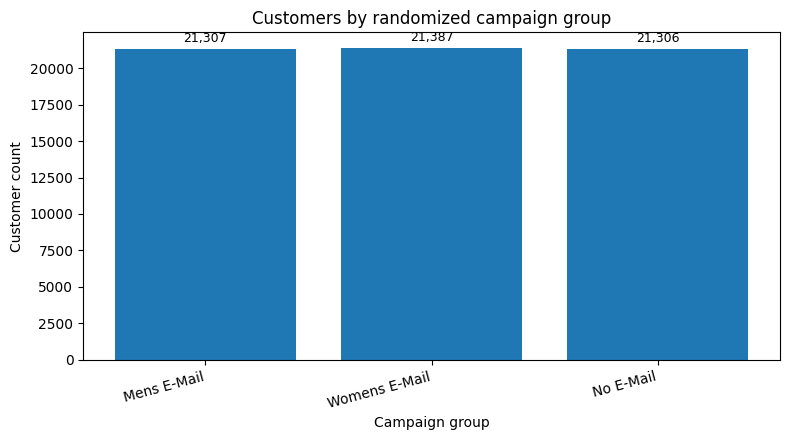

In [ ]:
segment_counts = (df['segment']
                  .value_counts()
                  .reindex(['Mens E-Mail', 'Womens E-Mail', 'No E-Mail'])
                  .rename_axis('segment')
                  .reset_index(name='n'))
segment_counts['share'] = segment_counts['n'] / len(df)
display(segment_counts)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(segment_counts['segment'], segment_counts['n'])
ax.set_title('Customers by randomized campaign group')
ax.set_ylabel('Customer count')
ax.set_xlabel('Campaign group')
label_bars(ax, fmt='{:,.0f}')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:** The three arms are almost exactly equal in size: Men's Email has **21,307**, Women's Email has **21,387**, and No Email has **21,306** customers. This strongly supports using treatment-control comparisons as the initial causal baseline.

,feature,No E-Mail_mean,Mens E-Mail_mean,Womens E-Mail_mean,max_abs_pairwise_smd,anova_p_value
0,recency,5.7497,5.7736,5.7678,0.0068,0.7631
1,history,240.8827,242.8359,242.5366,0.0076,0.6980
2,mens,0.5532,0.5509,0.5489,0.0086,0.6717
3,womens,0.5476,0.5514,0.5501,0.0076,0.7289
4,newbie,0.5020,0.5015,0.5032,0.0034,0.9339


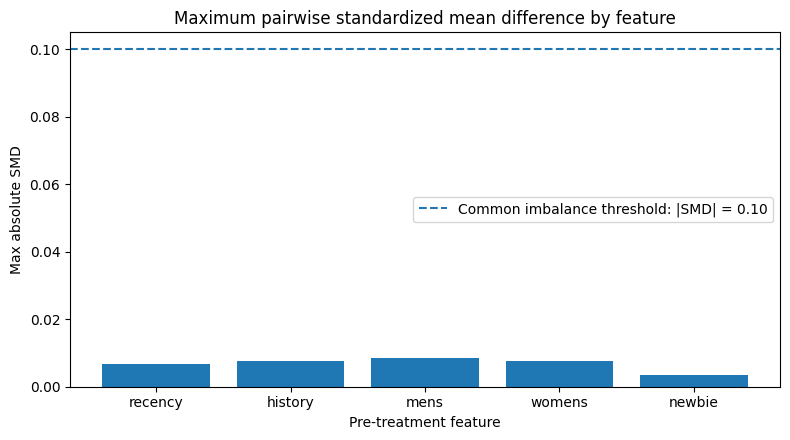

In [ ]:
# Balance checks for numeric and binary pre-treatment variables.
numeric_balance_rows = []
for feature in ['recency', 'history', 'mens', 'womens', 'newbie']:
    groups = {seg: df.loc[df['segment'] == seg, feature] for seg in segment_order}
    row = {'feature': feature}
    for seg in segment_order:
        row[f'{seg}_mean'] = groups[seg].mean()
    row['max_abs_pairwise_smd'] = max(
        abs(smd(groups[a], groups[b]))
        for i, a in enumerate(segment_order)
        for b in segment_order[i+1:]
    )
    row['anova_p_value'] = stats.f_oneway(*groups.values()).pvalue
    numeric_balance_rows.append(row)

numeric_balance = pd.DataFrame(numeric_balance_rows)
display(numeric_balance)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(numeric_balance['feature'], numeric_balance['max_abs_pairwise_smd'])
ax.axhline(0.1, linestyle='--', label='Common imbalance threshold: |SMD| = 0.10')
ax.set_title('Maximum pairwise standardized mean difference by feature')
ax.set_ylabel('Max absolute SMD')
ax.set_xlabel('Pre-treatment feature')
ax.legend()
plt.tight_layout()
plt.show()

,feature,cramers_v,chi_square_p_value
0,history_segment,0.0101,0.3580
1,zip_code,0.0047,0.5795
2,channel,0.0053,0.4580


### Distribution of `history_segment` by randomized group

segment,Mens E-Mail,No E-Mail,Womens E-Mail
history_segment,,,
1) $0 - $100,36.2500,35.7300,35.6900
2) $100 - $200,22.0200,22.7000,22.1000
3) $200 - $350,19.2000,18.9800,19.4300
4) $350 - $500,9.8400,9.9700,10.2300
5) $500 - $750,7.5000,7.7500,7.7700
"6) $750 - $1,000",3.0200,2.9200,2.7700
"7) $1,000 +",2.1800,1.9500,2.0000


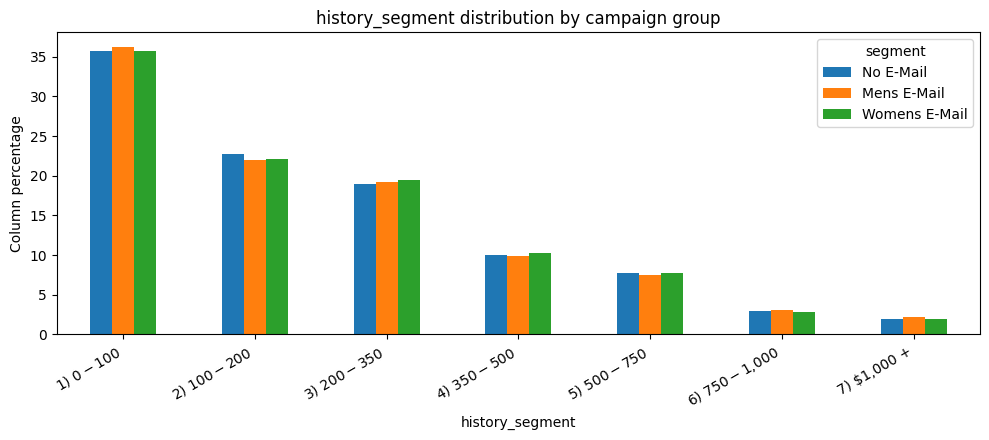

### Distribution of `zip_code` by randomized group

segment,Mens E-Mail,No E-Mail,Womens E-Mail
zip_code,,,
Rural,15.2200,14.7300,14.8700
Surburban,44.5900,45.1800,45.1200
Urban,40.1900,40.0900,40.0100


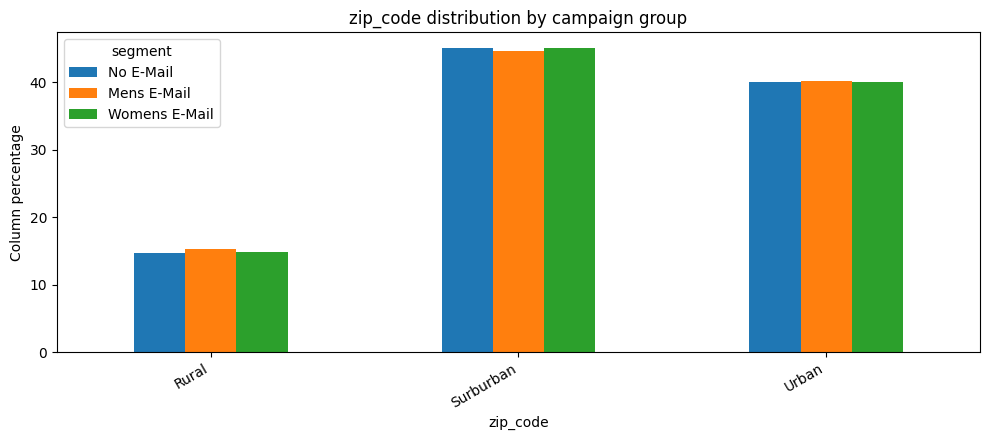

### Distribution of `channel` by randomized group

segment,Mens E-Mail,No E-Mail,Womens E-Mail
channel,,,
Multichannel,12.0900,12.2300,12.0600
Phone,43.3700,43.7800,44.2000
Web,44.5400,43.9900,43.7400


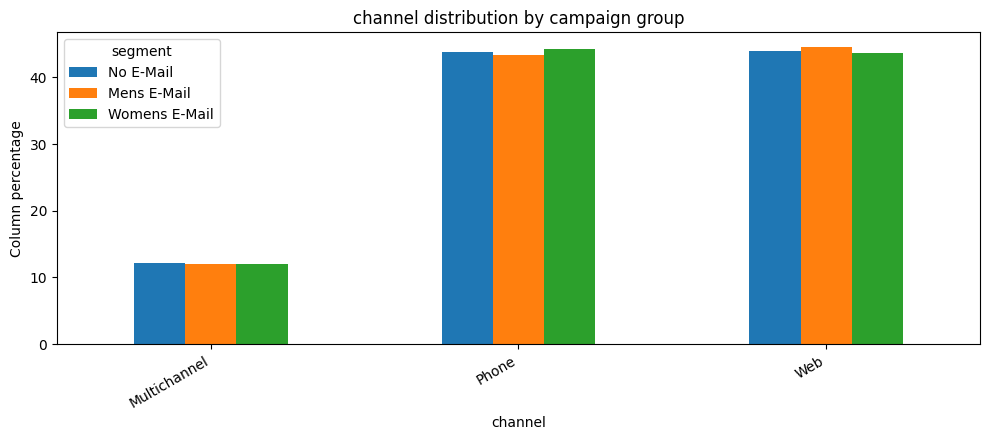

In [ ]:
# Categorical balance checks using Cramer's V and chi-square tests.
cat_balance_rows = []
for feature in ['history_segment', 'zip_code', 'channel']:
    table = pd.crosstab(df[feature], df['segment'])
    v, p_value = cramers_v(table)
    cat_balance_rows.append({'feature': feature, "cramers_v": v, 'chi_square_p_value': p_value})
cat_balance = pd.DataFrame(cat_balance_rows)
display(cat_balance)

for feature in ['history_segment', 'zip_code', 'channel']:
    dist = pd.crosstab(df[feature], df['segment'], normalize='columns') * 100
    display(Markdown(f'### Distribution of `{feature}` by randomized group'))
    display(dist.round(2))
    ax = dist[segment_order].plot(kind='bar', figsize=(10, 4.5))
    ax.set_title(f'{feature} distribution by campaign group')
    ax.set_ylabel('Column percentage')
    ax.set_xlabel(feature)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

**Balance conclusion:** The campaign groups are balanced on observed pre-treatment variables. The largest numeric/binary feature SMD is **0.009**, far below the common 0.10 practical-imbalance threshold. The categorical differences are also tiny, with largest Cramer's V **0.010**. This does not prove perfect balance on unobserved traits, but it supports the randomized-design assumption and makes simple difference-in-means estimates credible for initial EDA.

# 3. Overall outcome rates by campaign group

This section answers: What are the average visit, conversion, and spend rates by campaign group? Which campaign appears to perform best overall?

In [ ]:
outcome_summary = (df.groupby('segment')
    .agg(n=('visit', 'size'),
         visit_rate=('visit', 'mean'),
         conversions=('conversion', 'sum'),
         conversion_rate=('conversion', 'mean'),
         avg_spend=('spend', 'mean'),
         total_spend=('spend', 'sum'),
         avg_spend_among_converters=('spend', lambda s: s[s > 0].mean()))
    .reindex(['Mens E-Mail', 'Womens E-Mail', 'No E-Mail']))

display(outcome_summary)

,n,visit_rate,conversions,conversion_rate,avg_spend,total_spend,avg_spend_among_converters
segment,,,,,,,
Mens E-Mail,21307,0.1828,267,0.0125,1.4226,"30,311.6900",113.5269
Womens E-Mail,21387,0.1514,189,0.0088,1.0772,"23,038.1100",121.8948
No E-Mail,21306,0.1062,122,0.0057,0.6528,"13,908.3300",114.0027


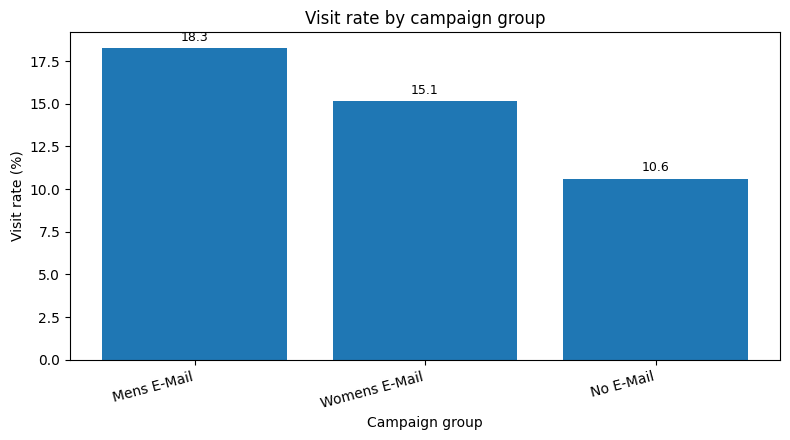

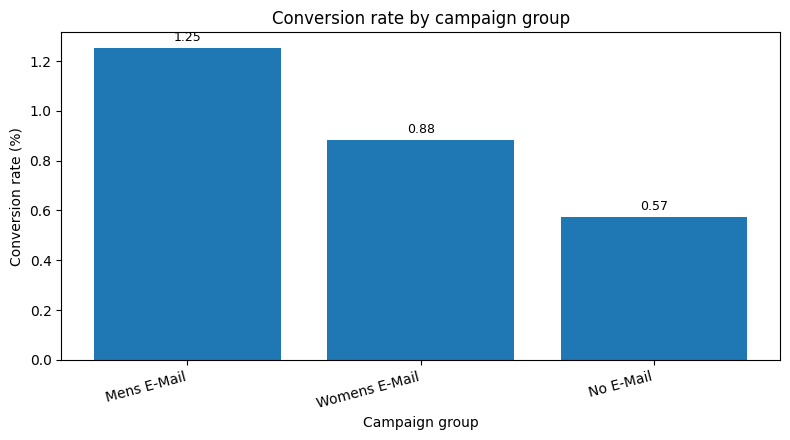

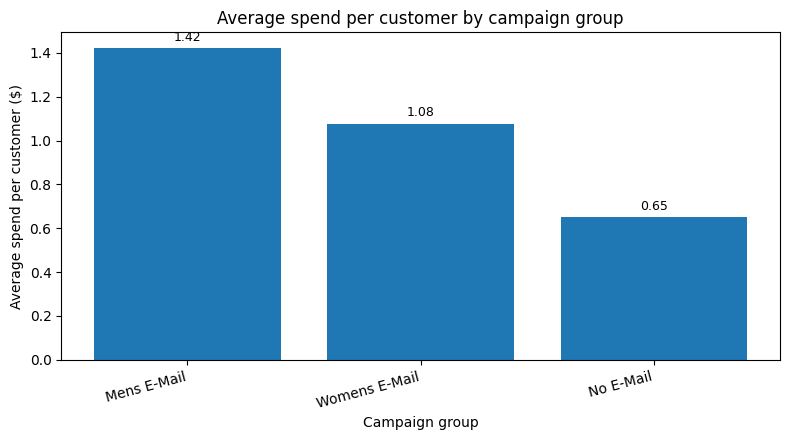

In [ ]:
# Visualize primary outcomes side by side.
plot_df = outcome_summary.reset_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(plot_df['segment'], plot_df['visit_rate'] * 100)
ax.set_title('Visit rate by campaign group')
ax.set_ylabel('Visit rate (%)')
ax.set_xlabel('Campaign group')
label_bars(ax, fmt='%.1f')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(plot_df['segment'], plot_df['conversion_rate'] * 100)
ax.set_title('Conversion rate by campaign group')
ax.set_ylabel('Conversion rate (%)')
ax.set_xlabel('Campaign group')
label_bars(ax, fmt='%.2f')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(plot_df['segment'], plot_df['avg_spend'])
ax.set_title('Average spend per customer by campaign group')
ax.set_ylabel('Average spend per customer ($)')
ax.set_xlabel('Campaign group')
label_bars(ax, fmt='%.2f')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Overall campaign-performance conclusion:** Men's Email performs best on all three average outcomes: visit rate, conversion rate, and average spend. Women's Email also performs better than no email, but the effect is smaller. This is an average-effect conclusion, not yet an individualized targeting rule.

- Men's Email visit lift vs. control: **7.66 pp**.
- Women's Email visit lift vs. control: **4.52 pp**.
- Men's Email conversion lift vs. control: **0.68 pp**.
- Women's Email conversion lift vs. control: **0.31 pp**.
- Men's Email spend lift vs. control: **\$0.77 per customer**.
- Women's Email spend lift vs. control: **\$0.42 per customer**.

# 4. Average treatment effects and uncertainty

Because this is a randomized campaign, simple treatment-control differences are reasonable first causal estimates. We still add confidence intervals and p-values so the final report can distinguish large, stable differences from noise.

In [ ]:
# Build treatment-control lift table for Mens, Womens, and Any E-Mail vs. No E-Mail.
control_df = df[df['segment'] == 'No E-Mail']
comparisons = {
    'Mens E-Mail vs No E-Mail': df[df['segment'] == 'Mens E-Mail'],
    'Womens E-Mail vs No E-Mail': df[df['segment'] == 'Womens E-Mail'],
    'Any E-Mail vs No E-Mail': df[df['email'] == 1]
}

rows = []
for label, treated_df in comparisons.items():
    for outcome in ['visit', 'conversion']:
        diff, lo, hi, p = two_prop_diff_ci(
            treated_df[outcome].sum(), len(treated_df),
            control_df[outcome].sum(), len(control_df)
        )
        rows.append({
            'comparison': label,
            'outcome': outcome,
            'treated_mean': treated_df[outcome].mean(),
            'control_mean': control_df[outcome].mean(),
            'lift': diff,
            'ci_low': lo,
            'ci_high': hi,
            'p_value': p,
            'incremental_count_or_amount': diff * len(treated_df)
        })
    diff, lo, hi, p = mean_diff_ci(treated_df['spend'], control_df['spend'])
    rows.append({
        'comparison': label,
        'outcome': 'spend',
        'treated_mean': treated_df['spend'].mean(),
        'control_mean': control_df['spend'].mean(),
        'lift': diff,
        'ci_low': lo,
        'ci_high': hi,
        'p_value': p,
        'incremental_count_or_amount': diff * len(treated_df)
    })

ate_table = pd.DataFrame(rows)
display(ate_table)

,comparison,outcome,treated_mean,control_mean,lift,ci_low,ci_high,p_value,incremental_count_or_amount
0,Mens E-Mail vs No E-Mail,visit,0.1828,0.1062,0.0766,0.0700,0.0832,0.0000,"1,631.8938"
1,Mens E-Mail vs No E-Mail,conversion,0.0125,0.0057,0.0068,0.0050,0.0086,0.0000,144.9943
2,Mens E-Mail vs No E-Mail,spend,1.4226,0.6528,0.7698,0.4851,1.0545,0.0000,"16,402.7072"
3,Womens E-Mail vs No E-Mail,visit,0.1514,0.1062,0.0452,0.0389,0.0516,0.0000,967.4005
4,Womens E-Mail vs No E-Mail,conversion,0.0088,0.0057,0.0031,0.0015,0.0047,0.0002,66.5362
5,Womens E-Mail vs No E-Mail,spend,1.0772,0.6528,0.4244,0.1690,0.6799,0.0011,"9,076.9041"
6,Any E-Mail vs No E-Mail,visit,0.1670,0.1062,0.0609,0.0554,0.0663,0.0000,"2,599.2943"
7,Any E-Mail vs No E-Mail,conversion,0.0107,0.0057,0.0050,0.0035,0.0064,0.0000,211.5305
8,Any E-Mail vs No E-Mail,spend,1.2496,0.6528,0.5968,0.3762,0.8174,0.0000,"25,479.6113"


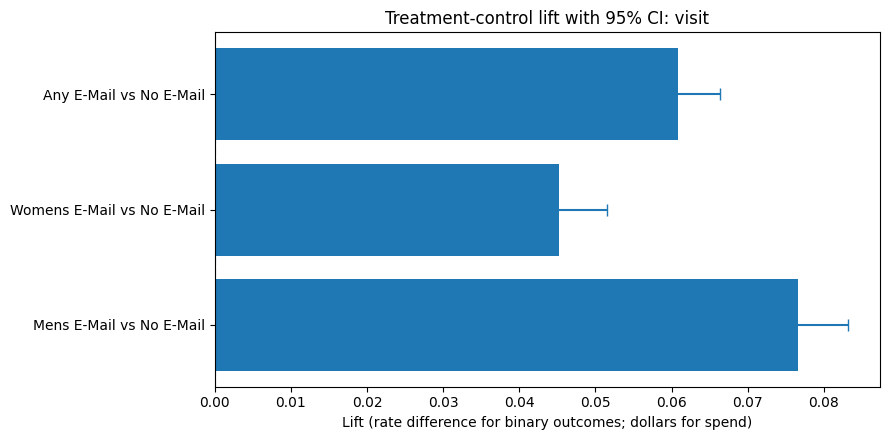

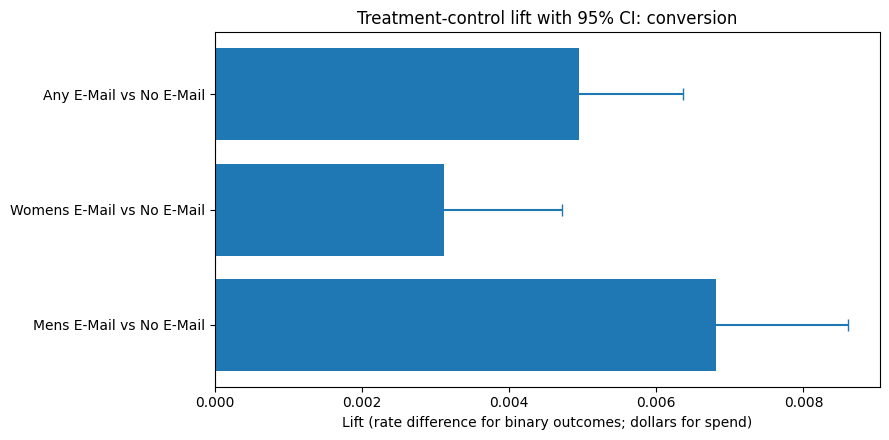

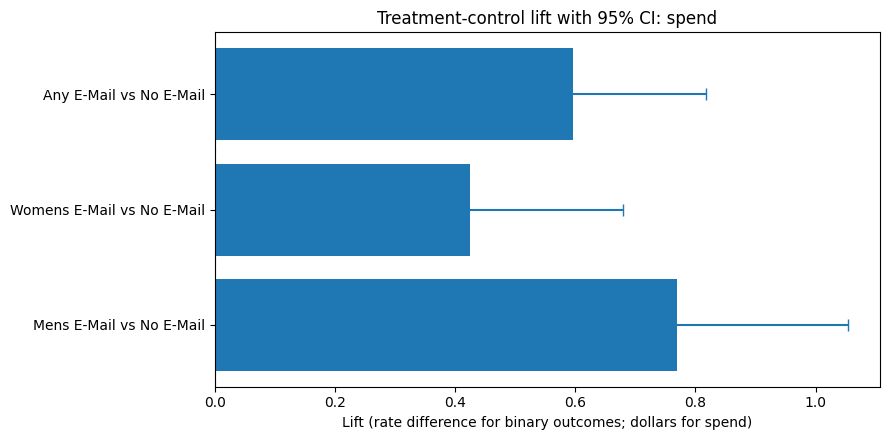

In [ ]:
# Plot lift with confidence intervals.
for outcome in ['visit', 'conversion', 'spend']:
    sub = ate_table[ate_table['outcome'] == outcome].copy()
    y = np.arange(len(sub))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.barh(y, sub['lift'])
    xerr = np.vstack([sub['lift'] - sub['ci_low'], sub['ci_high'] - sub['lift']])
    ax.errorbar(sub['lift'], y, xerr=xerr, fmt='none', capsize=4)
    ax.axvline(0, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(sub['comparison'])
    ax.set_title(f'Treatment-control lift with 95% CI: {outcome}')
    ax.set_xlabel('Lift (rate difference for binary outcomes; dollars for spend)')
    plt.tight_layout()
    plt.show()

**ATE interpretation:** Sending email works on average. Any Email vs. Control yields approximately **2,599 incremental visits**, **212 incremental conversions**, and **$25,480 incremental spend/revenue among the treated population**, using the control group as the counterfactual benchmark. Men's Email contributes the larger effect among the two email types.

# 5. Outcome sparsity and spend distribution

The proposal expected `visit` to be the easiest primary outcome because visits are more common than purchases. This section checks that with data.

,outcome,rate,count
0,visit,0.1468,9394
1,conversion,0.0090,578
2,positive_spend,0.0090,578


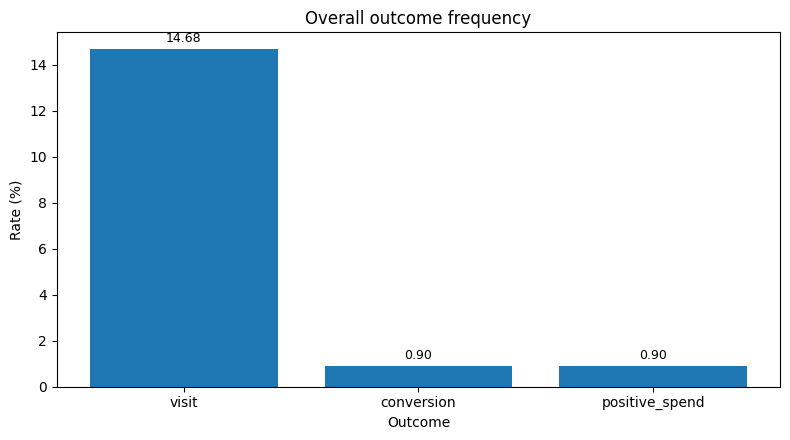

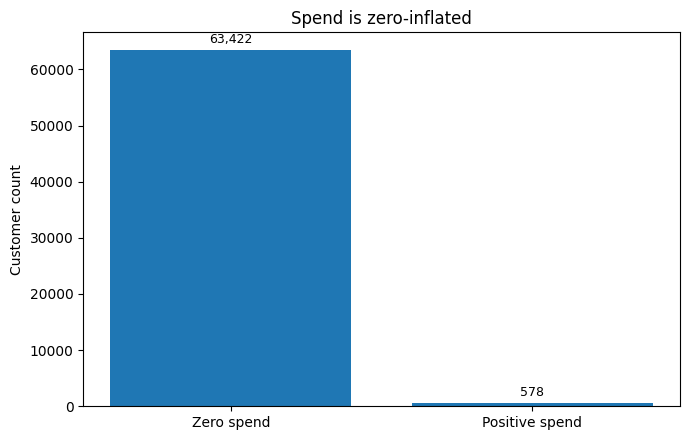

,positive_spend
count,578.0000
mean,116.3635
std,107.8715
min,29.9900
25%,32.2725
50%,80.7950
75%,153.3500
90%,256.4880
95%,362.2000
99%,499.0000


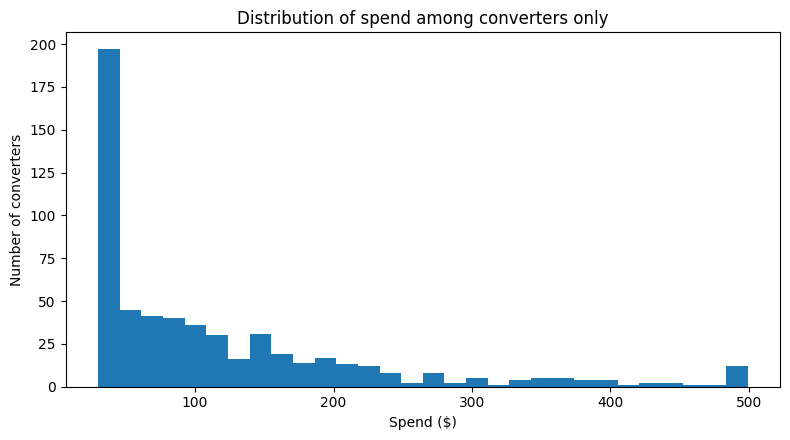

In [ ]:
overall_outcome_rates = pd.DataFrame({
    'outcome': ['visit', 'conversion', 'positive_spend'],
    'rate': [df['visit'].mean(), df['conversion'].mean(), (df['spend'] > 0).mean()],
    'count': [df['visit'].sum(), df['conversion'].sum(), (df['spend'] > 0).sum()]
})
display(overall_outcome_rates)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(overall_outcome_rates['outcome'], overall_outcome_rates['rate'] * 100)
ax.set_title('Overall outcome frequency')
ax.set_ylabel('Rate (%)')
ax.set_xlabel('Outcome')
label_bars(ax, fmt='%.2f')
plt.tight_layout()
plt.show()

spend_zero = pd.DataFrame({
    'category': ['Zero spend', 'Positive spend'],
    'n': [(df['spend'] == 0).sum(), (df['spend'] > 0).sum()]
})
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(spend_zero['category'], spend_zero['n'])
ax.set_title('Spend is zero-inflated')
ax.set_ylabel('Customer count')
label_bars(ax, fmt='{:,.0f}')
plt.tight_layout()
plt.show()

positive_spend = df.loc[df['spend'] > 0, 'spend']
display(positive_spend.describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_frame('positive_spend'))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(positive_spend, bins=30)
ax.set_title('Distribution of spend among converters only')
ax.set_xlabel('Spend ($)')
ax.set_ylabel('Number of converters')
plt.tight_layout()
plt.show()

**Sparsity conclusion:** `visit` has a much stronger signal than `conversion` and `spend`. The overall visit rate is **14.68%**, while the conversion rate is only **0.90%**. Since `spend > 0` exactly matches conversion in this dataset, spend is extremely zero-inflated. This supports using `visit` as the first uplift-modeling target, then checking whether conclusions are similar for conversion and spend.

# 6. Segment-level treatment effects

Average treatment effects answer whether the campaign worked overall. Uplift modeling asks whether the campaign worked **more for some customer types than others**. This section estimates treatment-control lift inside interpretable customer segments.

### Any email visit lift by `newbie`

,feature,value,treatment,n_total,n_treated,n_control,treated_mean,control_mean,lift,incremental_count_or_amount
1,newbie,1,Any E-Mail,32144,21449,10695,0.1416,0.0788,0.0628,"1,347.3495"
0,newbie,0,Any E-Mail,31856,21245,10611,0.1927,0.1337,0.0590,"1,252.9242"


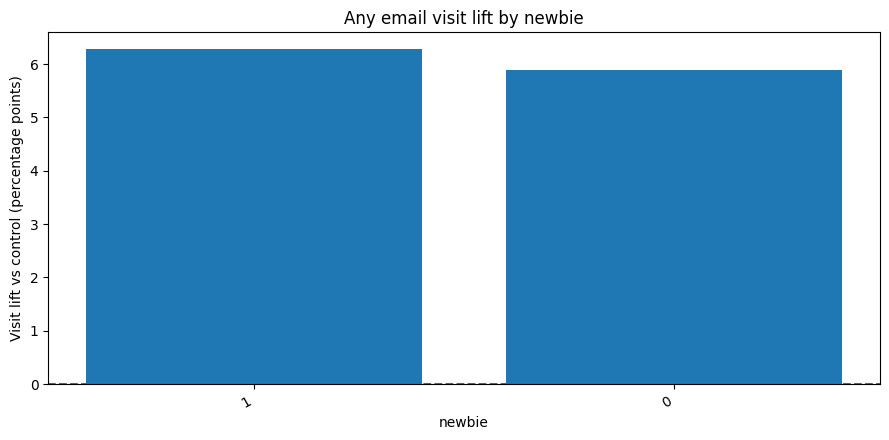

### Any email visit lift by `mens`

,feature,value,treatment,n_total,n_treated,n_control,treated_mean,control_mean,lift,incremental_count_or_amount
0,mens,0,Any E-Mail,28734,19215,9519,0.1681,0.0958,0.0723,"1,389.0419"
1,mens,1,Any E-Mail,35266,23479,11787,0.1662,0.1145,0.0517,"1,212.8806"


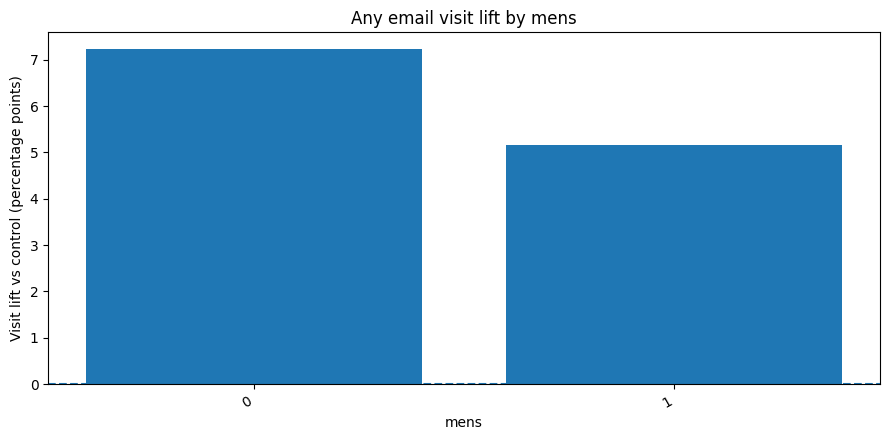

### Any email visit lift by `womens`

,feature,value,treatment,n_total,n_treated,n_control,treated_mean,control_mean,lift,incremental_count_or_amount
1,womens,1,Any E-Mail,35182,23514,11668,0.1892,0.1114,0.0778,"1,830.1680"
0,womens,0,Any E-Mail,28818,19180,9638,0.1398,0.0998,0.0400,767.5821


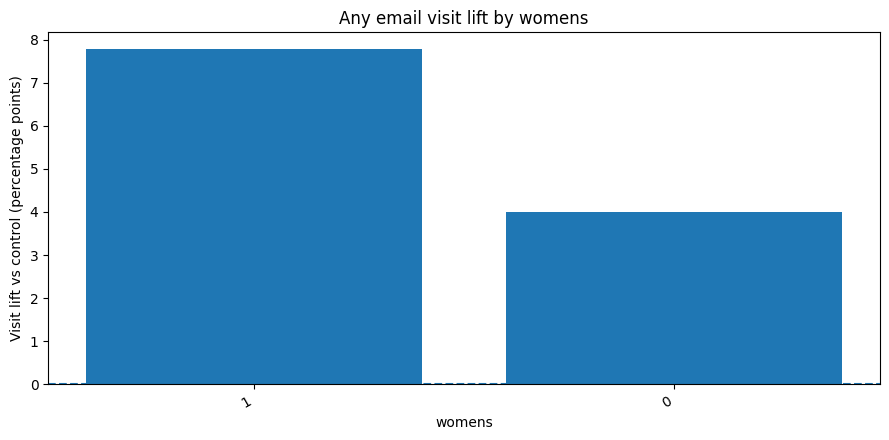

### Any email visit lift by `channel`

,feature,value,treatment,n_total,n_treated,n_control,treated_mean,control_mean,lift,incremental_count_or_amount
0,channel,Multichannel,Any E-Mail,7762,5156,2606,0.1936,0.1285,0.0650,335.1988
2,channel,Web,Any E-Mail,28217,18844,9373,0.1796,0.1189,0.0607,"1,144.3525"
1,channel,Phone,Any E-Mail,28021,18694,9327,0.1471,0.0872,0.0599,"1,120.5133"


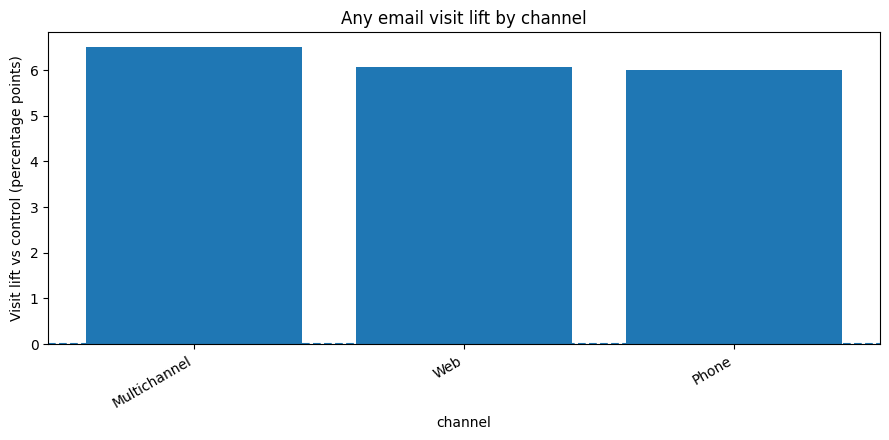

### Any email visit lift by `zip_code`

,feature,value,treatment,n_total,n_treated,n_control,treated_mean,control_mean,lift,incremental_count_or_amount
2,zip_code,Urban,Any E-Mail,25661,17119,8542,0.1601,0.0968,0.0633,"1,083.6114"
1,zip_code,Surburban,Any E-Mail,28776,19151,9625,0.1605,0.0990,0.0615,"1,177.8023"
0,zip_code,Rural,Any E-Mail,9563,6424,3139,0.2050,0.1536,0.0515,330.5814


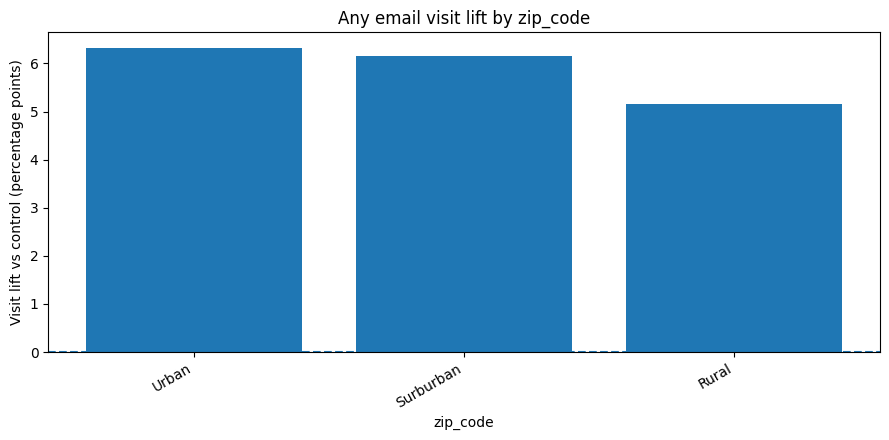

### Any email visit lift by `history_segment`

,feature,value,treatment,n_total,n_treated,n_control,treated_mean,control_mean,lift,incremental_count_or_amount
4,history_segment,5) $500 - $750,Any E-Mail,4911,3259,1652,0.1918,0.1096,0.0822,267.9304
6,history_segment,"7) $1,000 +",Any E-Mail,1308,892,416,0.2422,0.1659,0.0763,68.0481
3,history_segment,4) $350 - $500,Any E-Mail,6409,4285,2124,0.2145,0.1502,0.0643,275.4430
2,history_segment,3) $200 - $350,Any E-Mail,12289,8245,4044,0.1864,0.1264,0.0601,495.1615
5,history_segment,"6) $750 - $1,000",Any E-Mail,1859,1237,622,0.2126,0.1543,0.0583,72.0804
0,history_segment,1) $0 - $100,Any E-Mail,22970,15358,7612,0.1426,0.0849,0.0577,886.6280
1,history_segment,2) $100 - $200,Any E-Mail,14254,9418,4836,0.1467,0.0910,0.0558,525.1100


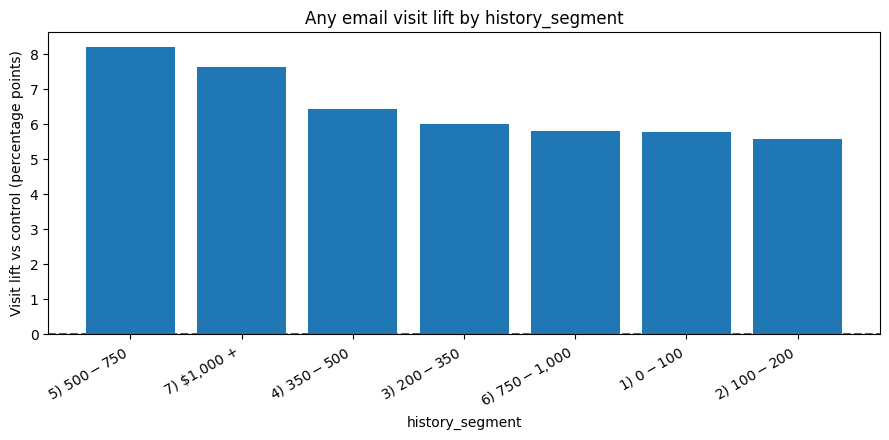

In [ ]:
def segment_lift(feature, outcome='visit', treatment='Any E-Mail'):
    rows = []
    for value, g in df.groupby(feature, observed=False):
        c = g[g['segment'] == 'No E-Mail']
        if treatment == 'Any E-Mail':
            t = g[g['email'] == 1]
        else:
            t = g[g['segment'] == treatment]
        if len(t) == 0 or len(c) == 0:
            continue
        rows.append({
            'feature': feature,
            'value': value,
            'treatment': treatment,
            'n_total': len(g),
            'n_treated': len(t),
            'n_control': len(c),
            'treated_mean': t[outcome].mean(),
            'control_mean': c[outcome].mean(),
            'lift': t[outcome].mean() - c[outcome].mean(),
            'incremental_count_or_amount': (t[outcome].mean() - c[outcome].mean()) * len(t)
        })
    return pd.DataFrame(rows)

segment_features = ['newbie', 'mens', 'womens', 'channel', 'zip_code', 'history_segment']
all_segment_lifts = []
for feature in segment_features:
    for outcome in ['visit', 'conversion', 'spend']:
        all_segment_lifts.append(segment_lift(feature, outcome=outcome, treatment='Any E-Mail'))
segment_lifts = pd.concat(all_segment_lifts, ignore_index=True)

# Display visit lift by segment because it is the primary outcome.
for feature in segment_features:
    display(Markdown(f'### Any email visit lift by `{feature}`'))
    tab = segment_lift(feature, outcome='visit', treatment='Any E-Mail').sort_values('lift', ascending=False)
    display(tab)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(tab['value'].astype(str), tab['lift'] * 100)
    ax.axhline(0, linestyle='--')
    ax.set_title(f'Any email visit lift by {feature}')
    ax.set_ylabel('Visit lift vs control (percentage points)')
    ax.set_xlabel(feature)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
# Compare Men's Email and Women's Email within the same segments.
campaign_segment_rows = []
for feature in segment_features:
    for value, g in df.groupby(feature, observed=False):
        c = g[g['segment'] == 'No E-Mail']
        for campaign in ['Mens E-Mail', 'Womens E-Mail']:
            t = g[g['segment'] == campaign]
            if len(t) == 0 or len(c) == 0:
                continue
            campaign_segment_rows.append({
                'feature': feature,
                'value': value,
                'campaign': campaign,
                'n_treated': len(t),
                'n_control': len(c),
                'visit_lift': t['visit'].mean() - c['visit'].mean(),
                'conversion_lift': t['conversion'].mean() - c['conversion'].mean(),
                'spend_lift': t['spend'].mean() - c['spend'].mean(),
            })
campaign_segment_lift = pd.DataFrame(campaign_segment_rows)

display(Markdown('### Largest campaign-specific visit lifts'))
display(campaign_segment_lift.sort_values('visit_lift', ascending=False).head(15))

display(Markdown('### Largest campaign-specific conversion lifts'))
display(campaign_segment_lift.sort_values('conversion_lift', ascending=False).head(15))

display(Markdown('### Largest campaign-specific spend lifts'))
display(campaign_segment_lift.sort_values('spend_lift', ascending=False).head(15))

### Largest campaign-specific visit lifts

,feature,value,campaign,n_treated,n_control,visit_lift,conversion_lift,spend_lift
32,history_segment,5) $500 - $750,Mens E-Mail,1597,1652,0.0990,0.0083,1.1030
36,history_segment,"7) $1,000 +",Mens E-Mail,464,416,0.0971,0.0093,1.3221
30,history_segment,4) $350 - $500,Mens E-Mail,2097,2124,0.0892,0.0087,1.5689
28,history_segment,3) $200 - $350,Mens E-Mail,4090,4044,0.0844,0.0085,0.5366
12,channel,Multichannel,Mens E-Mail,2577,2606,0.0829,0.0102,1.2091
10,womens,1,Mens E-Mail,11749,11668,0.0826,0.0074,0.8412
6,mens,1,Mens E-Mail,11739,11787,0.0816,0.0077,0.8966
22,zip_code,Urban,Mens E-Mail,8563,8542,0.0796,0.0066,0.7365
0,newbie,0,Mens E-Mail,10621,10611,0.0778,0.0062,0.5780
14,channel,Phone,Mens E-Mail,9240,9327,0.0756,0.0055,0.5641


### Largest campaign-specific conversion lifts

,feature,value,campaign,n_treated,n_control,visit_lift,conversion_lift,spend_lift
34,history_segment,"6) $750 - $1,000",Mens E-Mail,644,622,0.0615,0.0200,1.5341
37,history_segment,"7) $1,000 +",Womens E-Mail,428,416,0.0538,0.0113,2.5068
33,history_segment,5) $500 - $750,Womens E-Mail,1662,1652,0.0661,0.0102,1.2857
12,channel,Multichannel,Mens E-Mail,2577,2606,0.0829,0.0102,1.2091
36,history_segment,"7) $1,000 +",Mens E-Mail,464,416,0.0971,0.0093,1.3221
30,history_segment,4) $350 - $500,Mens E-Mail,2097,2124,0.0892,0.0087,1.5689
35,history_segment,"6) $750 - $1,000",Womens E-Mail,593,622,0.0548,0.0087,0.6483
28,history_segment,3) $200 - $350,Mens E-Mail,4090,4044,0.0844,0.0085,0.5366
32,history_segment,5) $500 - $750,Mens E-Mail,1597,1652,0.0990,0.0083,1.1030
6,mens,1,Mens E-Mail,11739,11787,0.0816,0.0077,0.8966


### Largest campaign-specific spend lifts

,feature,value,campaign,n_treated,n_control,visit_lift,conversion_lift,spend_lift
37,history_segment,"7) $1,000 +",Womens E-Mail,428,416,0.0538,0.0113,2.5068
30,history_segment,4) $350 - $500,Mens E-Mail,2097,2124,0.0892,0.0087,1.5689
34,history_segment,"6) $750 - $1,000",Mens E-Mail,644,622,0.0615,0.0200,1.5341
36,history_segment,"7) $1,000 +",Mens E-Mail,464,416,0.0971,0.0093,1.3221
33,history_segment,5) $500 - $750,Womens E-Mail,1662,1652,0.0661,0.0102,1.2857
12,channel,Multichannel,Mens E-Mail,2577,2606,0.0829,0.0102,1.2091
13,channel,Multichannel,Womens E-Mail,2579,2606,0.0471,0.0071,1.1575
32,history_segment,5) $500 - $750,Mens E-Mail,1597,1652,0.0990,0.0083,1.1030
2,newbie,1,Mens E-Mail,10686,10695,0.0753,0.0074,0.9600
6,mens,1,Mens E-Mail,11739,11787,0.0816,0.0077,0.8966


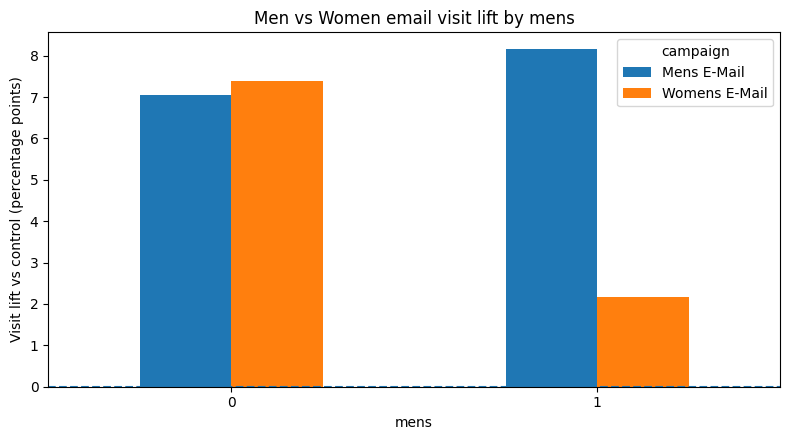

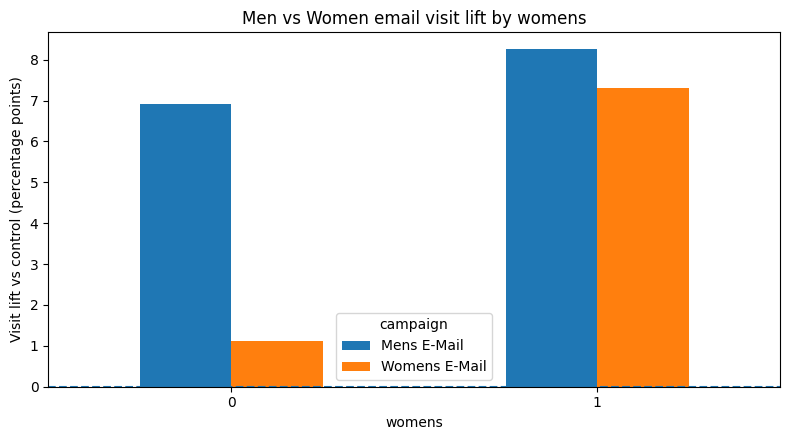

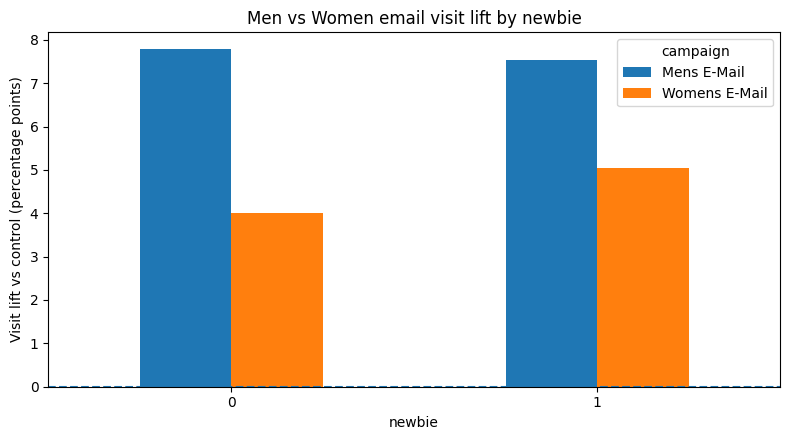

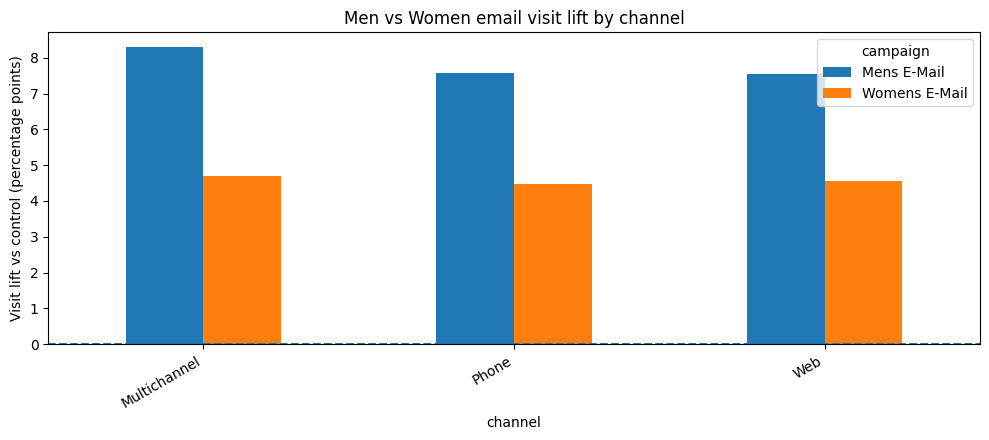

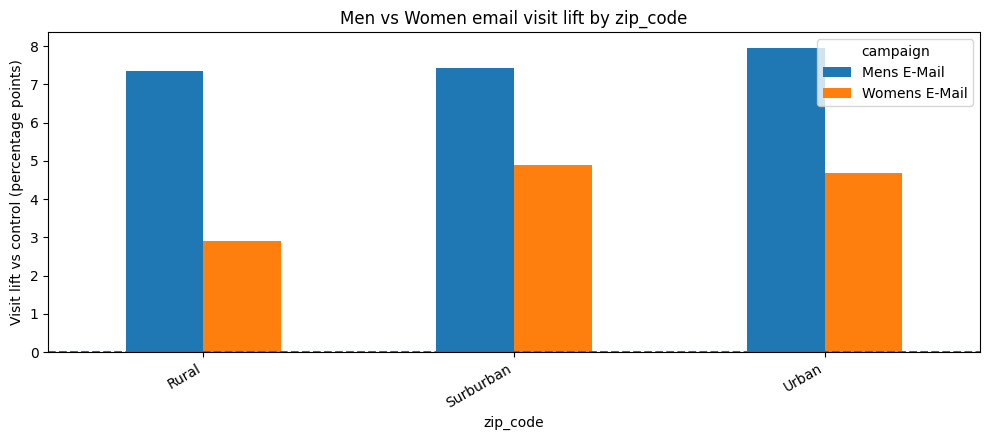

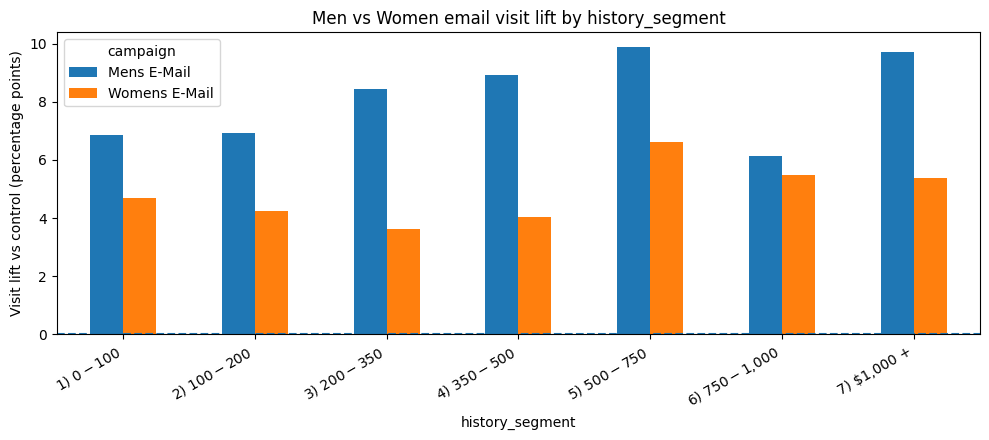

In [ ]:
# Visualize campaign-specific visit lift for key binary features.
for feature in ['mens', 'womens', 'newbie']:
    sub = campaign_segment_lift[campaign_segment_lift['feature'] == feature].copy()
    pivot = sub.pivot(index='value', columns='campaign', values='visit_lift') * 100
    ax = pivot.plot(kind='bar', figsize=(8, 4.5))
    ax.axhline(0, linestyle='--')
    ax.set_title(f'Men vs Women email visit lift by {feature}')
    ax.set_ylabel('Visit lift vs control (percentage points)')
    ax.set_xlabel(feature)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

for feature in ['channel', 'zip_code', 'history_segment']:
    sub = campaign_segment_lift[campaign_segment_lift['feature'] == feature].copy()
    pivot = sub.pivot(index='value', columns='campaign', values='visit_lift') * 100
    ax = pivot.plot(kind='bar', figsize=(10, 4.5))
    ax.axhline(0, linestyle='--')
    ax.set_title(f'Men vs Women email visit lift by {feature}')
    ax.set_ylabel('Visit lift vs control (percentage points)')
    ax.set_xlabel(feature)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

**Segment-level interpretation:** Treatment effects are not flat. The email campaign generally helps across many groups, but the lift varies by history segment, past product behavior, channel, and zip-code type. This is exactly why the final project should go beyond an average ATE and compare heterogeneous-treatment-effect methods.

A useful business interpretation is:

- The campaign is effective on average, so sending email is not harmful overall.
- Men's Email is usually the stronger average treatment arm.
- Some high-history customer groups show larger incremental visit and spend lifts, but conversion remains sparse, so final decisions should account for uncertainty and business value.
- Segment-level lift is still coarse. A final uplift model should estimate uplift at the customer level using all pre-treatment features together.

# 7. Relationships between customer history and outcomes

The proposal identifies customer history and recency as important input features. This section checks how they relate to baseline outcomes and treatment response.

### Mean visit by history segment and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
history_segment,,,
1) $0 - $100,0.0849,0.1534,0.1316
2) $100 - $200,0.0910,0.1601,0.1335
3) $200 - $350,0.1264,0.2108,0.1625
4) $350 - $500,0.1502,0.2394,0.1906
5) $500 - $750,0.1096,0.2085,0.1757
"6) $750 - $1,000",0.1543,0.2158,0.2091
"7) $1,000 +",0.1659,0.2629,0.2196


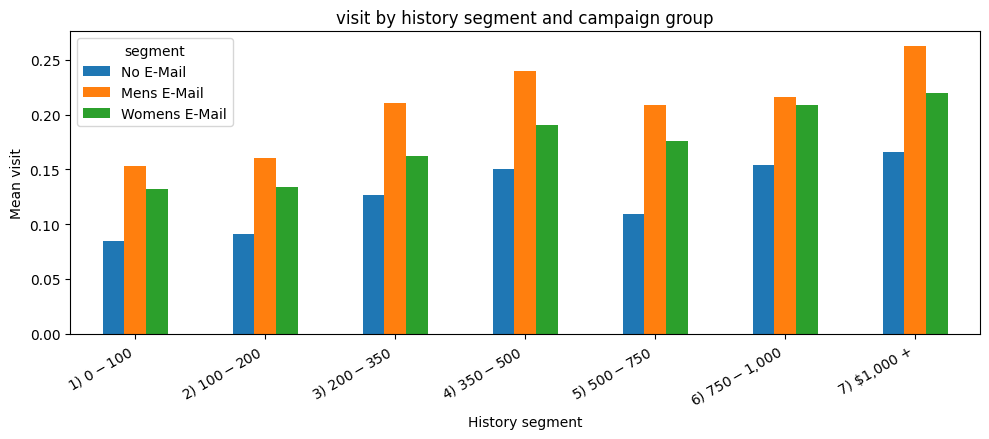

### Mean conversion by history segment and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
history_segment,,,
1) $0 - $100,0.0042,0.0092,0.0080
2) $100 - $200,0.0041,0.0090,0.0078
3) $200 - $350,0.0069,0.0154,0.0063
4) $350 - $500,0.0113,0.0200,0.0091
5) $500 - $750,0.0054,0.0138,0.0156
"6) $750 - $1,000",0.0048,0.0248,0.0135
"7) $1,000 +",0.0144,0.0237,0.0257


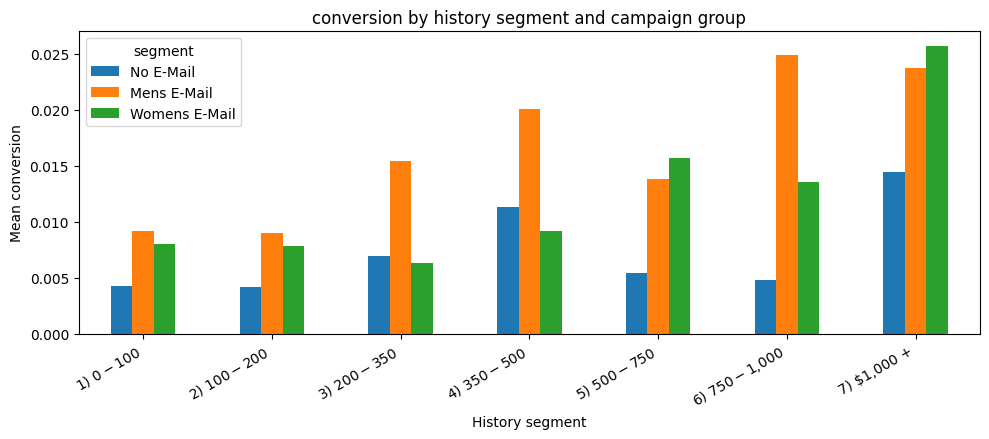

### Mean spend by history segment and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
history_segment,,,
1) $0 - $100,0.5169,1.0552,1.1427
2) $100 - $200,0.4229,1.1271,0.8813
3) $200 - $350,0.9329,1.4695,0.6097
4) $350 - $500,1.0103,2.5792,0.9094
5) $500 - $750,0.5389,1.6419,1.8245
"6) $750 - $1,000",0.3495,1.8837,0.9978
"7) $1,000 +",2.1698,3.4919,4.6766


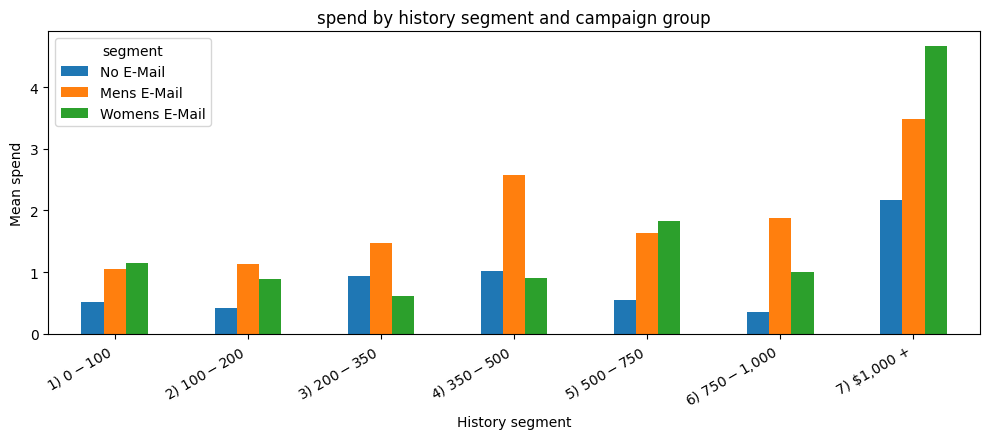

In [ ]:
# Outcome rates by history_segment and campaign.
for outcome in ['visit', 'conversion', 'spend']:
    pivot = df.pivot_table(index='history_segment', columns='segment', values=outcome, aggfunc='mean').reindex(columns=segment_order)
    display(Markdown(f'### Mean {outcome} by history segment and campaign group'))
    display(pivot)
    ax = pivot.plot(kind='bar', figsize=(10, 4.5))
    ax.set_title(f'{outcome} by history segment and campaign group')
    ax.set_ylabel(f'Mean {outcome}')
    ax.set_xlabel('History segment')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

### Mean visit by recency and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
recency,,,
1,0.1484,0.2332,0.1975
2,0.1343,0.2214,0.1774
3,0.1260,0.2089,0.1636
4,0.1116,0.1947,0.1412
5,0.1101,0.1683,0.1495
6,0.0949,0.1789,0.1484
7,0.1001,0.1571,0.1465
8,0.0902,0.1543,0.1390
9,0.0654,0.1484,0.1270


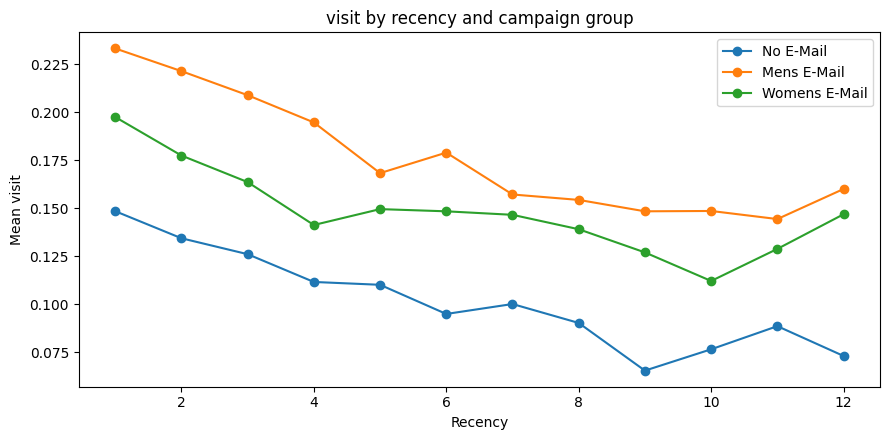

### Mean conversion by recency and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
recency,,,
1,0.0091,0.0182,0.0142
2,0.0079,0.0145,0.0114
3,0.0103,0.0158,0.0085
4,0.0052,0.0142,0.0084
5,0.0046,0.0075,0.0085
6,0.0065,0.0092,0.0071
7,0.0028,0.0122,0.0044
8,0.0060,0.0085,0.0069
9,0.0024,0.0123,0.0081


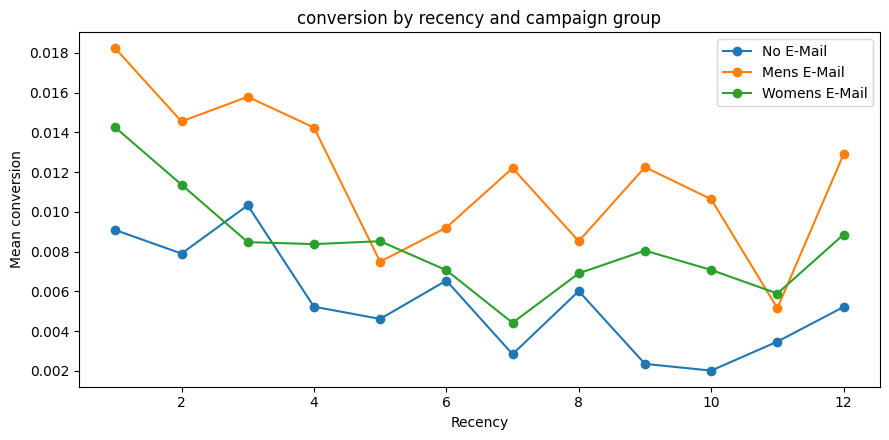

### Mean spend by recency and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
recency,,,
1,0.8452,1.8720,1.6618
2,1.1014,1.9035,1.2941
3,0.8882,2.2845,0.7707
4,0.4311,0.9450,1.8254
5,0.3835,1.0192,0.7910
6,0.7532,1.0656,0.8827
7,0.3823,1.6999,0.3286
8,1.2986,0.6682,1.5607
9,0.3086,1.1453,0.8513


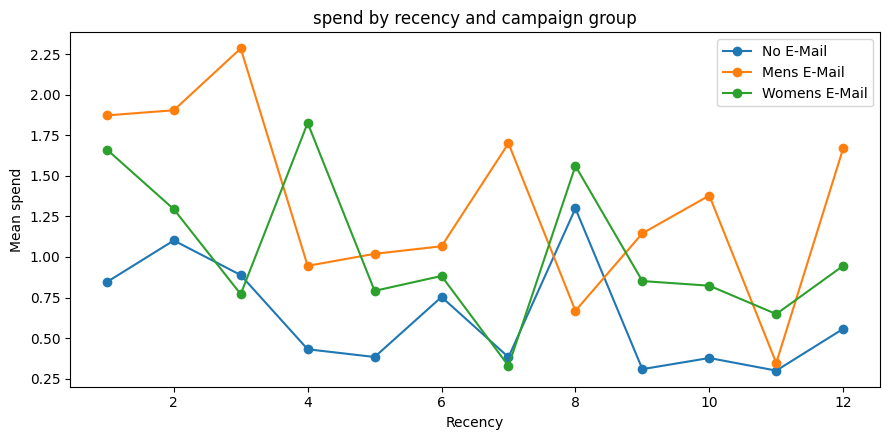

In [ ]:
# Recency as an ordered variable.
recency_summary = df.groupby(['recency', 'segment'])[['visit', 'conversion', 'spend']].mean().reset_index()

for outcome in ['visit', 'conversion', 'spend']:
    pivot = recency_summary.pivot(index='recency', columns='segment', values=outcome).reindex(columns=segment_order)
    display(Markdown(f'### Mean {outcome} by recency and campaign group'))
    display(pivot.head(12))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for col in pivot.columns:
        ax.plot(pivot.index, pivot[col], marker='o', label=col)
    ax.set_title(f'{outcome} by recency and campaign group')
    ax.set_xlabel('Recency')
    ax.set_ylabel(f'Mean {outcome}')
    ax.legend()
    plt.tight_layout()
    plt.show()

**History/recency interpretation:** Historical spend and recency are related to outcome levels, but the business question is not only who has high baseline response. The final model needs to distinguish high baseline response from high incremental response. For example, a high-history customer may have high visit probability even without email, so uplift evaluation is still needed.

# 8. Customer channel, zip type, and product-behavior patterns

This section explores whether channel, zip type, and prior men's/women's product behavior are associated with different response levels.

### Mean visit by channel and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
channel,,,
Multichannel,0.1285,0.2115,0.1756
Phone,0.0872,0.1628,0.1318
Web,0.1189,0.1944,0.1645


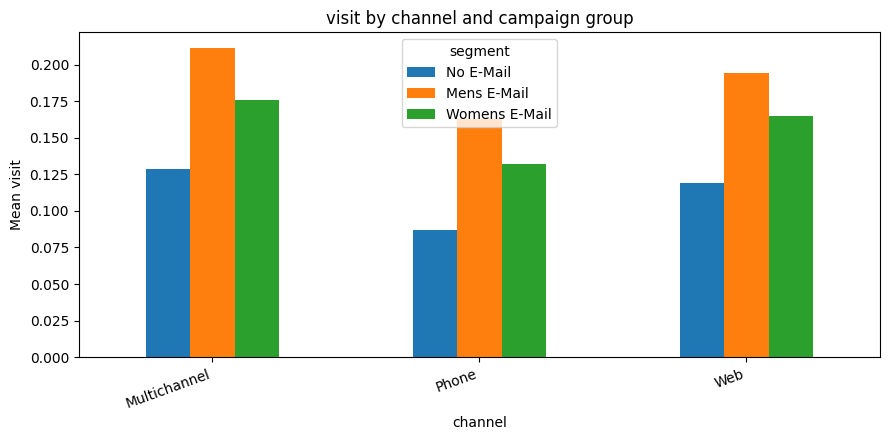

### Mean conversion by channel and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
channel,,,
Multichannel,0.0069,0.0171,0.0140
Phone,0.0054,0.0108,0.0071
Web,0.0058,0.0130,0.0092


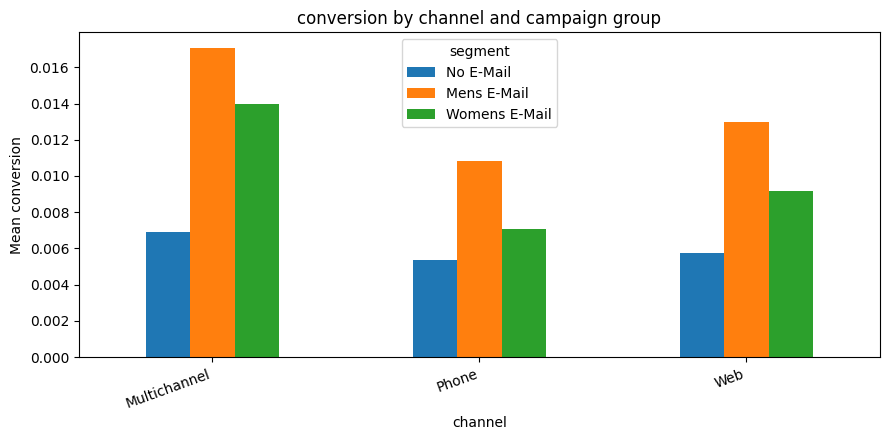

### Mean spend by channel and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
channel,,,
Multichannel,0.6157,1.8249,1.7733
Phone,0.6445,1.2085,0.8769
Web,0.6714,1.5218,1.0877


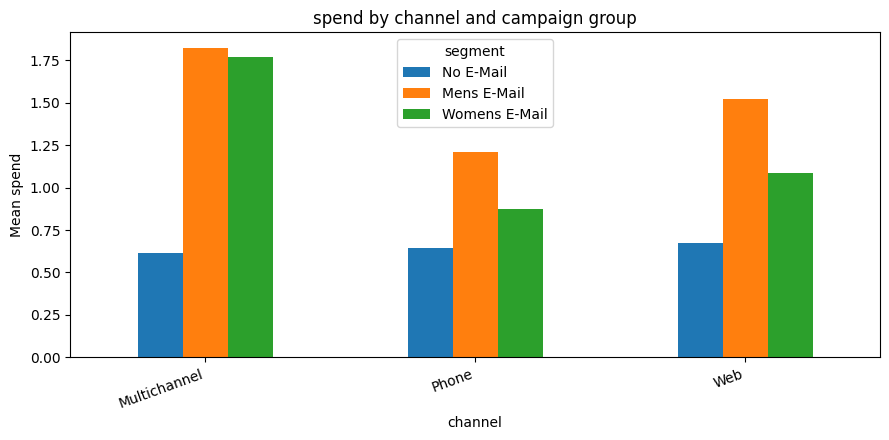

### Mean visit by zip_code and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
zip_code,,,
Rural,0.1536,0.2270,0.1826
Surburban,0.0990,0.1734,0.1479
Urban,0.0968,0.1765,0.1438


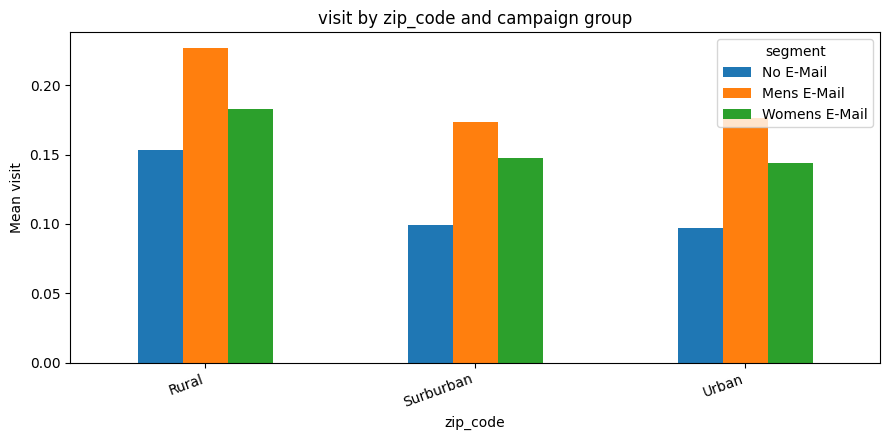

### Mean conversion by zip_code and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
zip_code,,,
Rural,0.0083,0.0136,0.0116
Surburban,0.0050,0.0124,0.0076
Urban,0.0056,0.0123,0.0092


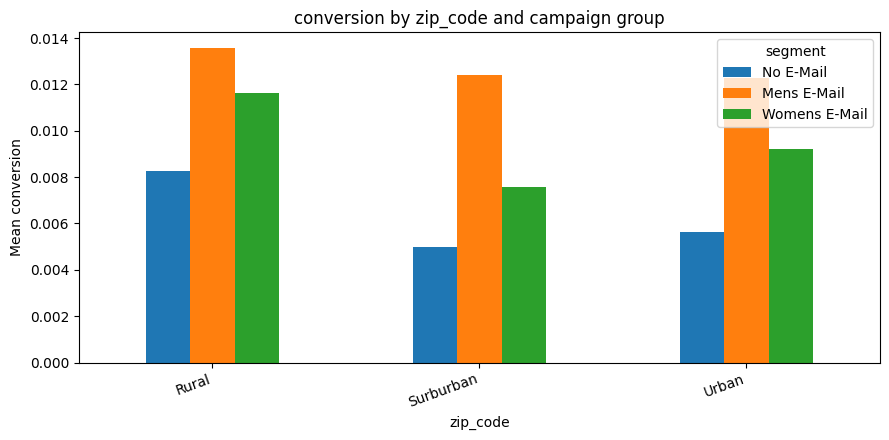

### Mean spend by zip_code and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
zip_code,,,
Rural,0.7671,1.5226,1.2820
Surburban,0.6694,1.4733,0.8466
Urban,0.5920,1.3285,1.2611


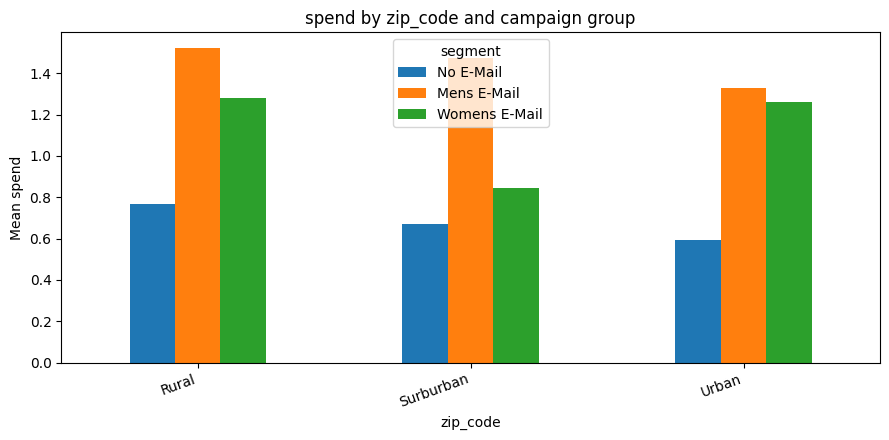

### Mean visit by mens and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
mens,,,
0,0.0958,0.1664,0.1698
1,0.1145,0.1961,0.1363


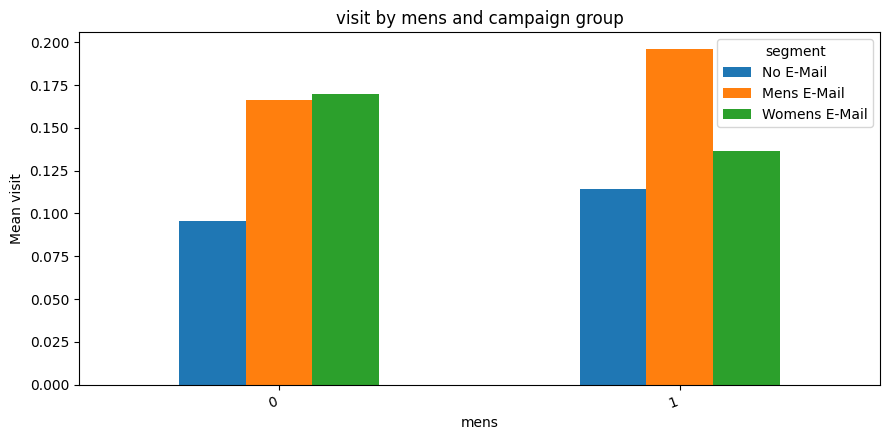

### Mean conversion by mens and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
mens,,,
0,0.0051,0.0109,0.0103
1,0.0062,0.0139,0.0077


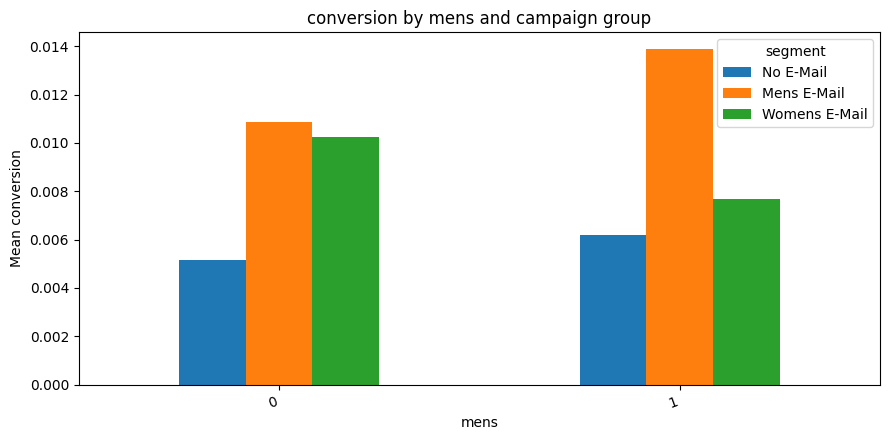

### Mean spend by mens and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
mens,,,
0,0.4906,1.1063,1.1222
1,0.7838,1.6804,1.0402


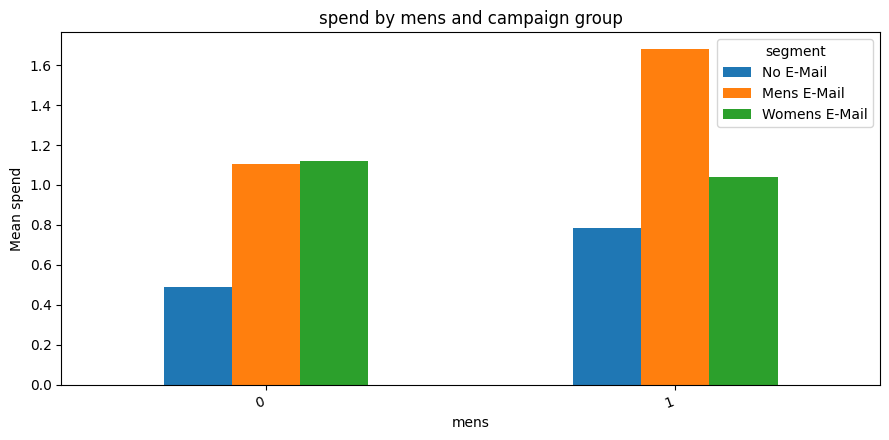

### Mean visit by womens and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
womens,,,
0,0.0998,0.1690,0.1109
1,0.1114,0.1940,0.1845


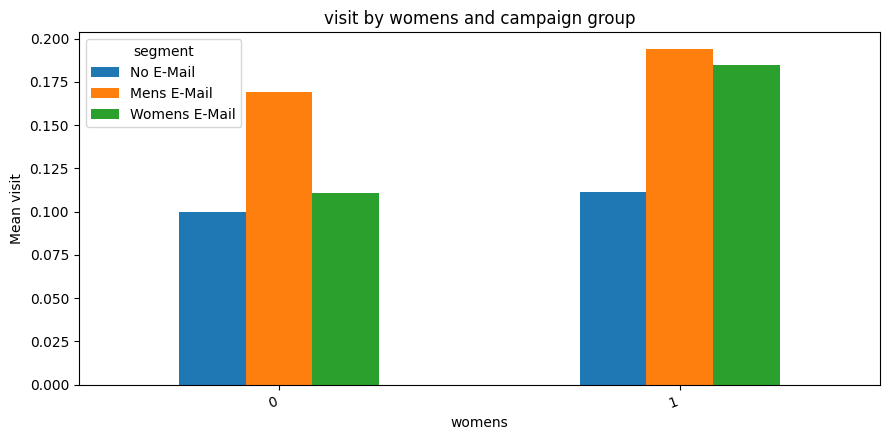

### Mean conversion by womens and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
womens,,,
0,0.0055,0.0115,0.0061
1,0.0059,0.0134,0.0110


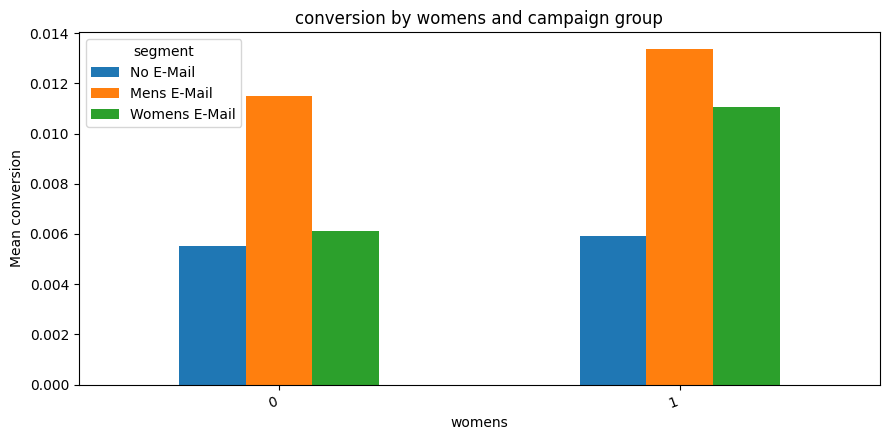

### Mean spend by womens and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
womens,,,
0,0.6954,1.3782,0.9738
1,0.6176,1.4588,1.1618


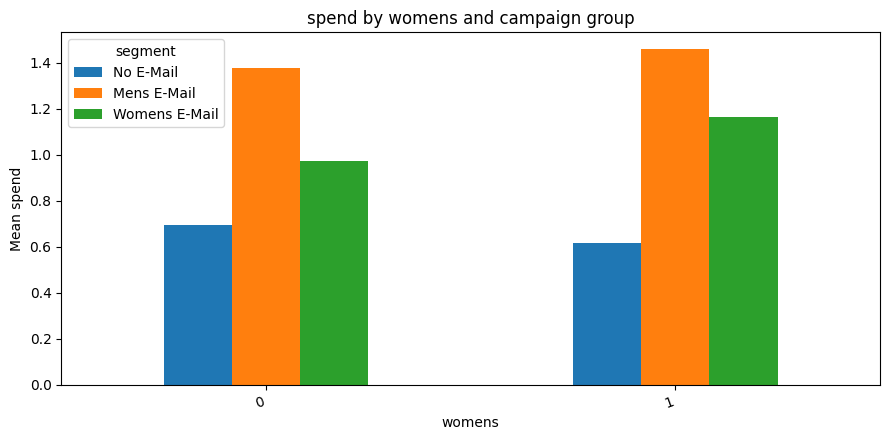

### Mean visit by newbie and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
newbie,,,
0,0.1337,0.2116,0.1739
1,0.0788,0.1541,0.1292


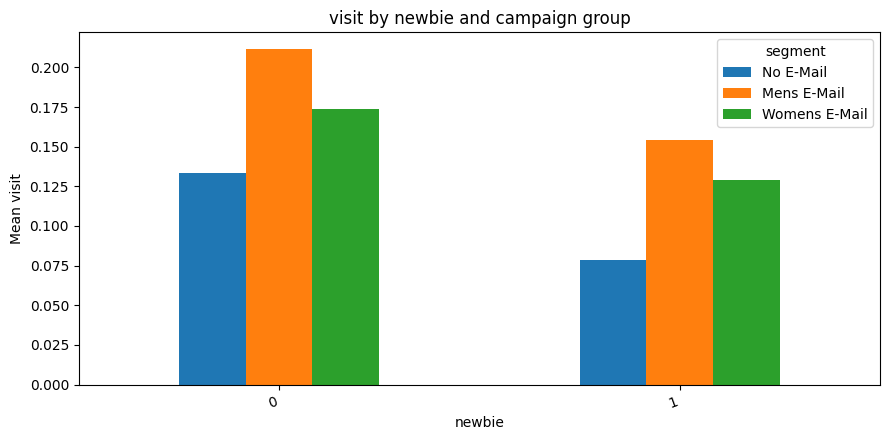

### Mean conversion by newbie and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
newbie,,,
0,0.0077,0.0139,0.0087
1,0.0037,0.0111,0.0090


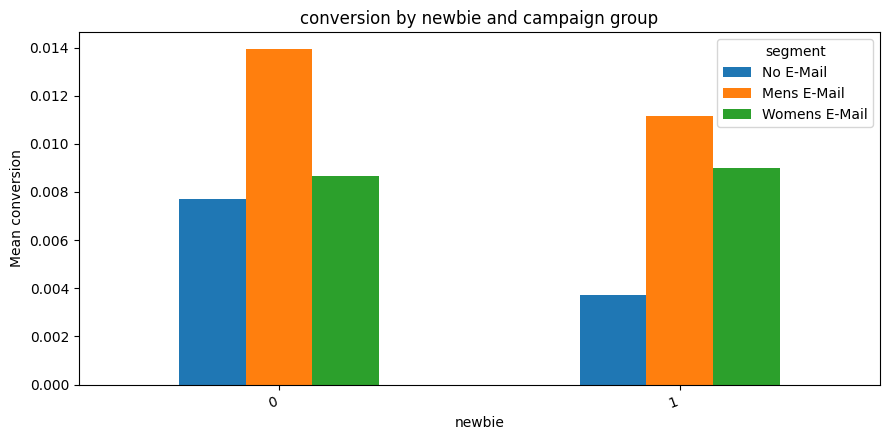

### Mean spend by newbie and campaign group

segment,No E-Mail,Mens E-Mail,Womens E-Mail
newbie,,,
0,0.9354,1.5133,1.0493
1,0.3724,1.3325,1.1047


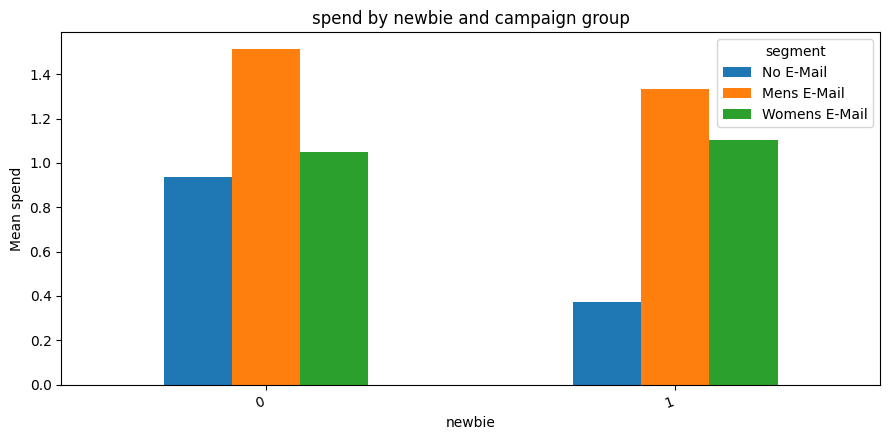

In [ ]:
# Channel and zip code outcome rates.
for feature in ['channel', 'zip_code', 'mens', 'womens', 'newbie']:
    for outcome in ['visit', 'conversion', 'spend']:
        pivot = df.pivot_table(index=feature, columns='segment', values=outcome, aggfunc='mean').reindex(columns=segment_order)
        display(Markdown(f'### Mean {outcome} by {feature} and campaign group'))
        display(pivot)
        ax = pivot.plot(kind='bar', figsize=(9, 4.5))
        ax.set_title(f'{outcome} by {feature} and campaign group')
        ax.set_ylabel(f'Mean {outcome}')
        ax.set_xlabel(feature)
        plt.xticks(rotation=20, ha='right')
        plt.tight_layout()
        plt.show()

**Customer-segment interpretation:** The campaign is not equally strong for all groups. Channel and product-history variables should stay in the final feature set because they help identify customer context. In particular, prior product behavior (`mens`, `womens`) matters for comparing Men's Email and Women's Email, while channel helps separate customers who historically bought via web, phone, or multiple channels.

# 9. ROI and business interpretation sanity check

The data contains outcomes and spend, but it does **not** contain the true campaign cost, profit margin, or gross margin. Therefore, ROI here is a sensitivity analysis, not a final finance result.

We evaluate two simple assumptions:

1. **Email-only cost:** $0.05 per contacted customer.
2. **Email + incentive cost:** $2.05 per contacted customer.

For conversion-based value, we assume $50 profit per incremental conversion as a placeholder. For spend-based value, we treat incremental spend as revenue and subtract campaign cost. In the final project, the team should replace these assumptions with the chosen business values.

,strategy,cost_assumption,n_targeted,conversion_lift,spend_lift_per_customer,conversion_value_profit_per_customer,conversion_based_net_profit_per_customer,spend_based_net_revenue_per_customer,break_even_conversion_value
0,Mens E-Mail vs No E-Mail,Email only cost,21307,0.0068,0.7698,0.3403,0.2903,0.7198,7.3475
1,Mens E-Mail vs No E-Mail,Email + incentive cost,21307,0.0068,0.7698,0.3403,-1.7097,-1.2802,301.2488
2,Womens E-Mail vs No E-Mail,Email only cost,21387,0.0031,0.4244,0.1556,0.1056,0.3744,16.0717
3,Womens E-Mail vs No E-Mail,Email + incentive cost,21387,0.0031,0.4244,0.1556,-1.8944,-1.6256,658.9399
4,Any E-Mail vs No E-Mail,Email only cost,42694,0.0050,0.5968,0.2477,0.1977,0.5468,10.0917
5,Any E-Mail vs No E-Mail,Email + incentive cost,42694,0.0050,0.5968,0.2477,-1.8023,-1.4532,413.7593


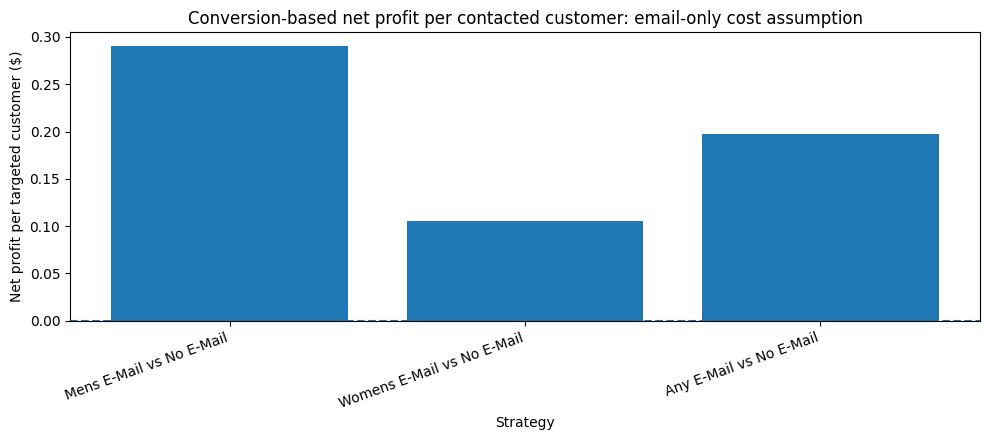

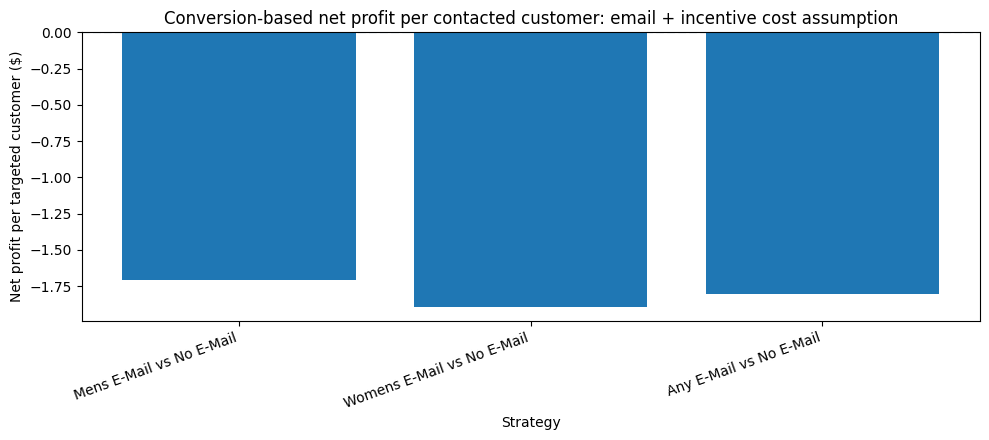

In [ ]:
# ROI sensitivity based on ATE estimates.
profit_per_conversion = 50.00
email_only_cost = 0.05
email_plus_incentive_cost = 2.05

roi_rows = []
for label, treated_df in comparisons.items():
    conv_lift = treated_df['conversion'].mean() - control_df['conversion'].mean()
    spend_lift = treated_df['spend'].mean() - control_df['spend'].mean()
    for cost_label, cost in [('Email only cost', email_only_cost), ('Email + incentive cost', email_plus_incentive_cost)]:
        roi_rows.append({
            'strategy': label,
            'cost_assumption': cost_label,
            'n_targeted': len(treated_df),
            'conversion_lift': conv_lift,
            'spend_lift_per_customer': spend_lift,
            'conversion_value_profit_per_customer': conv_lift * profit_per_conversion,
            'conversion_based_net_profit_per_customer': conv_lift * profit_per_conversion - cost,
            'spend_based_net_revenue_per_customer': spend_lift - cost,
            'break_even_conversion_value': cost / conv_lift if conv_lift > 0 else np.nan
        })
roi_table = pd.DataFrame(roi_rows)
display(roi_table)

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_roi = roi_table[roi_table['cost_assumption'] == 'Email only cost']
ax.bar(plot_roi['strategy'], plot_roi['conversion_based_net_profit_per_customer'])
ax.axhline(0, linestyle='--')
ax.set_title('Conversion-based net profit per contacted customer: email-only cost assumption')
ax.set_ylabel('Net profit per targeted customer ($)')
ax.set_xlabel('Strategy')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_roi = roi_table[roi_table['cost_assumption'] == 'Email + incentive cost']
ax.bar(plot_roi['strategy'], plot_roi['conversion_based_net_profit_per_customer'])
ax.axhline(0, linestyle='--')
ax.set_title('Conversion-based net profit per contacted customer: email + incentive cost assumption')
ax.set_ylabel('Net profit per targeted customer ($)')
ax.set_xlabel('Strategy')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**ROI interpretation:** Under a very low email-only cost, the campaign looks economically reasonable. Under a $2.05 cost per customer, the conversion lift is too small to cover cost unless conversion value is much higher than the placeholder. This is one reason an uplift model can matter: if cost is non-trivial, the business should avoid sending to customers with weak or negative incremental value.

# 10. EDA answer table for the proposal questions

This table translates the exploratory results into direct answers for the project write-up.

In [ ]:
eda_answers = pd.DataFrame([
    ['1. How many customers are in each group?',
     f"Mens E-Mail = {segment_counts.loc[segment_counts.segment == 'Mens E-Mail', 'n'].iloc[0]:,}; Womens E-Mail = {segment_counts.loc[segment_counts.segment == 'Womens E-Mail', 'n'].iloc[0]:,}; No E-Mail = {segment_counts.loc[segment_counts.segment == 'No E-Mail', 'n'].iloc[0]:,}.",
     'Use the treatment group count chart.'],
    ['2. Are the groups balanced?',
     f"Yes on observed features. Max pairwise SMD across numeric/binary features is {numeric_balance['max_abs_pairwise_smd'].max():.3f}; categorical Cramer\'s V values are all near zero.",
     'Use the balance tables and feature distribution charts.'],
    ['3. Are customer attributes similar across groups?',
     'Yes. Recency, history, product indicators, new-customer status, zip type, channel, and history segment have very similar distributions across arms.',
     'This supports randomized-comparison credibility.'],
    ['4. What are average outcomes by campaign group?',
     'Mens E-Mail has the highest visit rate, conversion rate, and average spend; Womens E-Mail is second; No E-Mail is lowest.',
     'Use the campaign outcome summary table and bar charts.'],
    ['5. Which campaign appears best overall?',
     'Mens E-Mail appears best overall by visit lift, conversion lift, and spend lift vs control.',
     'This is an average-effect conclusion, not a final individualized policy.'],
    ['6. Are there segment differences?',
     'Yes. Lift varies by history segment, prior product behavior, channel, zip type, and new-customer status.',
     'This motivates uplift modeling and heterogeneous treatment-effect estimation.'],
    ['7. Did any email increase visits/conversions/spend?',
     'Yes. Any email improves all three outcomes vs No E-Mail.',
     'Use the ATE table with confidence intervals.'],
    ['8. Did Men and Women emails differ?',
     'Yes. Mens E-Mail has the larger average lift in this dataset.',
     'Use the campaign-specific lift charts.'],
    ['9. What should be the primary outcome?',
     'Visit should be primary because it is much less sparse than conversion and spend.',
     'Conversion and spend should be secondary robustness/business metrics.'],
    ['10. What are the main risks before modeling?',
     'Outcome sparsity, spend zero inflation, and evaluating uplift without observing individual counterfactuals.',
     'Use uplift-specific metrics later: decile lift, uplift/Qini curves, and ROI policy value.']
], columns=['question', 'data-backed answer', 'where used in report'])
display(eda_answers)

,question,data-backed answer,where used in report
0,1. How many customers are in each group?,"Mens E-Mail = 21,307; Womens E-Mail = 21,387; ...",Use the treatment group count chart.
1,2. Are the groups balanced?,Yes on observed features. Max pairwise SMD acr...,Use the balance tables and feature distributio...
2,3. Are customer attributes similar across groups?,"Yes. Recency, history, product indicators, new...",This supports randomized-comparison credibility.
3,4. What are average outcomes by campaign group?,"Mens E-Mail has the highest visit rate, conver...",Use the campaign outcome summary table and bar...
4,5. Which campaign appears best overall?,Mens E-Mail appears best overall by visit lift...,"This is an average-effect conclusion, not a fi..."
5,6. Are there segment differences?,"Yes. Lift varies by history segment, prior pro...",This motivates uplift modeling and heterogeneo...
6,7. Did any email increase visits/conversions/s...,Yes. Any email improves all three outcomes vs ...,Use the ATE table with confidence intervals.
7,8. Did Men and Women emails differ?,Yes. Mens E-Mail has the larger average lift i...,Use the campaign-specific lift charts.
8,9. What should be the primary outcome?,Visit should be primary because it is much les...,Conversion and spend should be secondary robus...
9,10. What are the main risks before modeling?,"Outcome sparsity, spend zero inflation, and ev...",Use uplift-specific metrics later: decile lift...


# 11. Modeling implications and next steps

The EDA supports the project direction and provides the baseline results needed before machine learning.

## Recommended final modeling comparison

To respond to the feedback that we should not only try uplift scores, the final project should compare several mutually supporting methods:

1. **Difference in means / ATE:** model-free causal baseline from the randomized experiment.
2. **Regression adjustment:** logistic or linear model with treatment indicators and covariates; interactions can test heterogeneity.
3. **S-learner:** one model using covariates plus treatment, then score each customer under treatment and control.
4. **T-learner / two-model approach:** separate treated and control models, then subtract predictions.
5. **Transformed outcome or IPW-style estimator:** useful literature-supported alternative for CATE/uplift estimation.
6. **Direct uplift tree / causal tree / causal forest, if allowed:** directly searches for heterogeneous treatment effects.

## Evaluation plan

Classical metrics such as ROC AUC, precision, recall, and F1 are useful only for the **ordinary response-model baseline**. They do not prove that the model ranks customers by incremental response. The final uplift evaluation should therefore include:

- Uplift-by-decile tables.
- Qini curve or uplift curve.
- Policy-value comparison: send everyone, send no one, response-model targeting, uplift-model targeting, and ROI-positive targeting.
- Separate checks for `visit`, `conversion`, and `spend`.

## Final EDA recommendation

Start the final project with `visit` because it has enough signal. Then validate with `conversion` and `spend` because those are closer to business value. Keep the three-arm structure for the final extension because the data suggests Men's Email and Women's Email have different average and segment-level effects.

# Appendix: Optional export of key tables

Run the next cell if you want CSV versions of the summary tables for the report or slides.

In [ ]:
OUTPUT_DIR = Path('hillstrom_eda_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

segment_counts.to_csv(OUTPUT_DIR / 'segment_counts.csv', index=False)
numeric_balance.to_csv(OUTPUT_DIR / 'numeric_balance.csv', index=False)
cat_balance.to_csv(OUTPUT_DIR / 'categorical_balance.csv', index=False)
outcome_summary.reset_index().to_csv(OUTPUT_DIR / 'outcome_summary_by_segment.csv', index=False)
ate_table.to_csv(OUTPUT_DIR / 'ate_table.csv', index=False)
segment_lifts.to_csv(OUTPUT_DIR / 'segment_lifts_any_email.csv', index=False)
campaign_segment_lift.to_csv(OUTPUT_DIR / 'campaign_specific_segment_lifts.csv', index=False)
roi_table.to_csv(OUTPUT_DIR / 'roi_sensitivity.csv', index=False)
eda_answers.to_csv(OUTPUT_DIR / 'eda_answers_for_proposal.csv', index=False)

print(f'Exported tables to: {OUTPUT_DIR.resolve()}')

Exported tables to: /content/hillstrom_eda_outputs
